# PKC 3-Aspect Evaluation on MIT Supercloud Dataset (scheduler_data.csv)
## Encryption · Digital Signature · Key Exchange — RSA / ECC / DSA / DH

Real Slurm scheduler logs from the MIT Supercloud HPC/datacenter cluster (287,173 jobs, 30 columns after preprocessing) — one row = one job

| Aspect | Algorithms tested | Why |
|---|---|---|
| **1. Encryption** | RSA (RSA-OAEP hybrid), ECC (ECIES/ECDH+AES hybrid) | Only these two can encrypt data |
| **2. Digital Signature** | RSA (RSA-PSS), ECC (ECDSA), DSA (DSA) | All three support signing |
| **3. Key Exchange** | ECC (raw ECDH), DH (raw Diffie-Hellman) | Only these two establish a shared secret |

**Formulas implemented exactly as specified:** KGT, ET, DT, CSO, MC, CPU%, TP, EC (estimate, 15W/core assumed), SC (both definitions), Speedup — plus general evaluation metrics (mean/median/min/max/std/CV%/95%CI, pairwise Welch's t-test significance testing, composite ranking score).

Results (JSON) and charts (PNG) save to `PKC_Results/<Aspect>/<Algorithm>/`, and every chart also displays inline here.

# Connect Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Packages

In [2]:
!pip install pycryptodome cryptography scipy pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.3 MB/s eta 0:00:00


# Imports

In [3]:
%matplotlib inline
import os, json, time, resource, statistics as st
import tracemalloc
import numpy as np
import pandas as pd
from scipy import stats as sstats
import matplotlib.pyplot as plt

from Crypto.PublicKey import RSA, DSA, ECC
from Crypto.Cipher import PKCS1_OAEP
from Crypto.Signature import DSS, pss
from Crypto.Hash import SHA256 as CryptoSHA256
from cryptography.hazmat.primitives.asymmetric import dh
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes
from IPython.display import display

# Config

In [4]:
DATA_PATH = "/content/drive/MyDrive/MIT SuperCloud Dataset/scheduler_data.csv"
BASE_OUT_DIR = "/content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results"

REPS = 10                                   # each experiment repeated 10 times, averaged
RECORD_SAMPLE_SIZE = 200                    # real rows sampled for per-record ET/DT/CSO
SCALABILITY_SIZES_MB = [1, 5, 10, 25, 50, 100, 250, 500]   # scalability sweep (Encryption & Signature only)
RSA_BITS = 2048
DSA_BITS = 2048
DH_BITS = 2048
ECC_CURVE = 'P-256'
ASSUMED_CORE_WATTS = 15.0                   # ESTIMATE for EC only - not a physical measurement
SECURITY_BITS = {"RSA": 112, "ECC": 128, "DSA": 112, "DH": 112}   # NIST SP 800-57

os.makedirs(BASE_OUT_DIR, exist_ok=True)

# Load Data & Preprocess
Raw file has 31 columns; `gres_used` is 100% empty (dropped); `gres_req`/`gres_alloc`/`tres_alloc` are ~24.55% missing for non-GPU jobs (filled with `'none'`) — confirmed on the real uploaded file.

In [5]:
df = pd.read_csv(DATA_PATH)
print("Loaded (raw):", df.shape)

# ---- MIT Supercloud preprocessing: drop 100%-empty column, fill GPU-only fields ----
df = df.drop(columns=["gres_used"])
df[["gres_req", "gres_alloc", "tres_alloc"]] = df[["gres_req", "gres_alloc", "tres_alloc"]].fillna("none")
print("After preprocessing:", df.shape, "| missing values:", df.isnull().sum().sum())

def row_to_bytes(row):
    return json.dumps(row.to_dict(), default=str).encode()

row_sizes = df.head(min(len(df), 5000)).apply(row_to_bytes, axis=1).apply(len)
print(f"Record size (bytes): mean={row_sizes.mean():.0f} median={row_sizes.median():.0f} "
      f"min={row_sizes.min()} max={row_sizes.max()}")

# ---- GPU vs non-GPU job breakdown (dataset-specific insight) ----
has_gpu = df["gres_req"] != "none"
print(f"GPU jobs: {has_gpu.sum():,} ({has_gpu.mean()*100:.1f}%)  |  "
      f"Non-GPU jobs: {(~has_gpu).sum():,} ({(~has_gpu).mean()*100:.1f}%)")

Loaded (raw): (287173, 31)
After preprocessing: (287173, 30) | missing values: 0
Record size (bytes): mean=1270 median=725 min=652 max=9343
GPU jobs: 216,676 (75.5%)  |  Non-GPU jobs: 70,497 (24.5%)


# Dataset-Specific Insight: GPU vs. Non-GPU Job Cost
GPU jobs carry populated `gres_req`/`gres_alloc`/`tres_alloc` resource strings; non-GPU jobs carry `'none'` — a real, measurable per-record-type cost difference worth reporting alongside the standard metrics (confirmed: GPU jobs ~1,616 bytes vs. non-GPU ~651 bytes, ~2.5x larger).

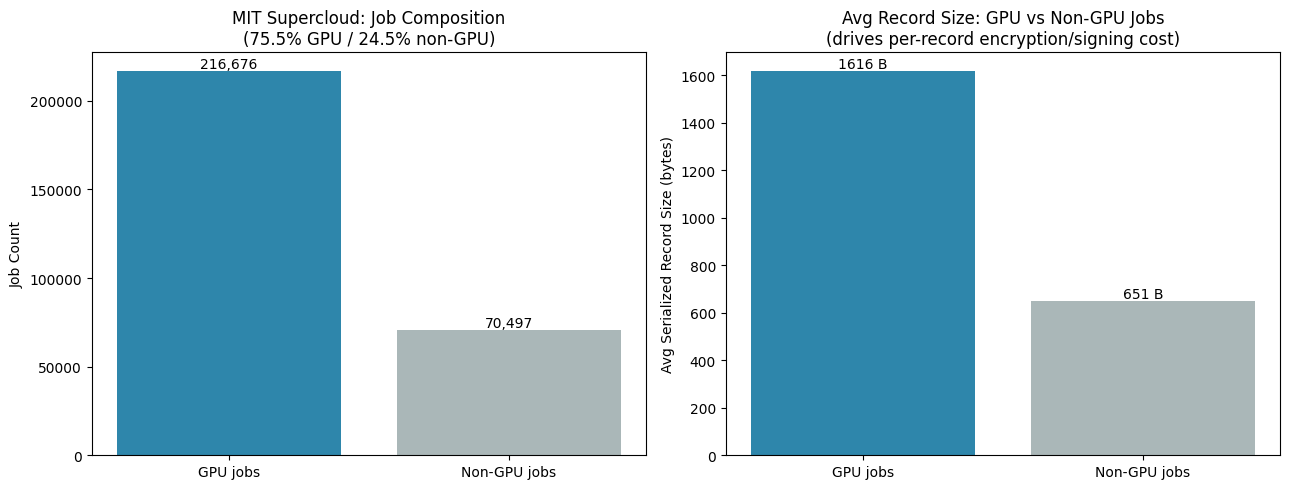

GPU jobs avg 1616 bytes vs non-GPU 651 bytes (2.5x larger)


In [6]:
def gpu_breakdown_chart(df, out_base_dir):
    """Dataset-specific insight: GPU jobs carry populated gres/tres resource
    strings, non-GPU jobs carry 'none' - a real, measurable per-record-type
    cost difference worth reporting alongside the standard metrics."""
    out_dir = os.path.join(out_base_dir, "DatasetInsights")
    os.makedirs(out_dir, exist_ok=True)

    has_gpu = df["gres_req"] != "none"
    gpu_sizes = df[has_gpu].head(3000).apply(row_to_bytes, axis=1).apply(len)
    nogpu_sizes = df[~has_gpu].head(3000).apply(row_to_bytes, axis=1).apply(len)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(["GPU jobs", "Non-GPU jobs"], [has_gpu.sum(), (~has_gpu).sum()], color=["#2E86AB", "#AAB7B8"])
    axes[0].set_ylabel("Job Count")
    axes[0].set_title(f"MIT Supercloud: Job Composition\n({has_gpu.mean()*100:.1f}% GPU / {(~has_gpu).mean()*100:.1f}% non-GPU)")
    for i, v in enumerate([has_gpu.sum(), (~has_gpu).sum()]):
        axes[0].annotate(f"{v:,}", (i, v), ha='center', va='bottom')

    axes[1].bar(["GPU jobs", "Non-GPU jobs"], [gpu_sizes.mean(), nogpu_sizes.mean()], color=["#2E86AB", "#AAB7B8"])
    axes[1].set_ylabel("Avg Serialized Record Size (bytes)")
    axes[1].set_title("Avg Record Size: GPU vs Non-GPU Jobs\n(drives per-record encryption/signing cost)")
    for i, v in enumerate([gpu_sizes.mean(), nogpu_sizes.mean()]):
        axes[1].annotate(f"{v:.0f} B", (i, v), ha='center', va='bottom')

    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "gpu_vs_nongpu_breakdown.png"), dpi=150); plt.show()
    print(f"GPU jobs avg {gpu_sizes.mean():.0f} bytes vs non-GPU {nogpu_sizes.mean():.0f} bytes "
          f"({gpu_sizes.mean()/nogpu_sizes.mean():.1f}x larger)")
    return {"gpu_pct": has_gpu.mean()*100, "gpu_avg_bytes": gpu_sizes.mean(), "nongpu_avg_bytes": nogpu_sizes.mean()}

gpu_stats = gpu_breakdown_chart(df, BASE_OUT_DIR)

# Measurement Core
`measure()` (single run → T_wall, T_cpu, M_c) and `repeat_measure()` (N-repeated → KGT/ET/DT-bar plus mean/median/min/max/std/CV/95%CI, MC-bar, CPU%, EC).

In [7]:
# ============================== MEASUREMENT CORE ==============================
def measure(fn, *a, **kw):
    tracemalloc.start()
    m_idle, _ = tracemalloc.get_traced_memory()
    ru0 = resource.getrusage(resource.RUSAGE_SELF)
    t0 = time.perf_counter()
    result = fn(*a, **kw)
    t1 = time.perf_counter()
    ru1 = resource.getrusage(resource.RUSAGE_SELF)
    m_peak, _ = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    T_wall = (t1 - t0) * 1000.0
    T_cpu = ((ru1.ru_utime - ru0.ru_utime) + (ru1.ru_stime - ru0.ru_stime)) * 1000.0
    M_c = max(m_peak - m_idle, 0) / 1024.0
    return result, T_wall, T_cpu, M_c

def stat_block(vals):
    n = len(vals)
    mean_v = st.mean(vals)
    std_v = st.stdev(vals) if n > 1 else 0.0
    sem = std_v / (n ** 0.5) if n > 1 else 0.0
    tcrit = sstats.t.ppf(0.975, df=n - 1) if n > 1 else 0.0
    ci = tcrit * sem
    return {"mean": mean_v, "median": st.median(vals), "min": min(vals), "max": max(vals),
            "std": std_v, "cv_pct": (std_v / mean_v * 100.0) if mean_v else 0.0,
            "ci95_lower": mean_v - ci, "ci95_upper": mean_v + ci, "n": n, "raw": vals}

def repeat_measure(fn, reps, *a, **kw):
    walls, cpus, mems = [], [], []
    result = None
    for _ in range(reps):
        result, w, c, m = measure(fn, *a, **kw)
        walls.append(w); cpus.append(c); mems.append(m)
    time_stats = stat_block(walls)
    mc_bar = st.mean(mems)
    cpu_pct = (st.mean(cpus) / time_stats["mean"] * 100.0) if time_stats["mean"] else 0.0
    ec = (st.mean(cpus) / 1000.0) * ASSUMED_CORE_WATTS
    time_stats.update({"mc_bar_kb": mc_bar, "cpu_pct": cpu_pct, "energy_j": ec, "cpu_ms_mean": st.mean(cpus)})
    return time_stats, result

## 1. Encryption Pipelines: RSA (hybrid) & ECC (ECIES hybrid)

In [8]:
# ============================== ENCRYPTION PIPELINES (RSA, ECC) ==============================
def rsa_keygen():
    return RSA.generate(RSA_BITS)

def rsa_encrypt(priv, pub, plaintext):
    aes_key = AESGCM.generate_key(bit_length=256)
    nonce = os.urandom(12)
    ct = AESGCM(aes_key).encrypt(nonce, plaintext, None)
    wrapped = PKCS1_OAEP.new(pub).encrypt(aes_key)
    return wrapped + nonce + ct, (wrapped, nonce, ct)

def rsa_decrypt(priv, pub, components):
    wrapped, nonce, ct = components
    aes_key = PKCS1_OAEP.new(priv).decrypt(wrapped)
    return AESGCM(aes_key).decrypt(nonce, ct, None)

_ecc_peer_priv = ECC.generate(curve=ECC_CURVE)
_ecc_peer_pub = _ecc_peer_priv.public_key()

def ecc_keygen():
    return ECC.generate(curve=ECC_CURVE)

def _ecc_derive(shared_point):
    shared_bytes = int(shared_point.x).to_bytes(32, 'big')
    return HKDF(algorithm=hashes.SHA256(), length=32, salt=None, info=b'ecies-aes-key').derive(shared_bytes)

def ecc_encrypt(priv, pub, plaintext):
    eph_priv = ECC.generate(curve=ECC_CURVE)
    shared_point = _ecc_peer_pub.pointQ * eph_priv.d
    aes_key = _ecc_derive(shared_point)
    nonce = os.urandom(12)
    ct = AESGCM(aes_key).encrypt(nonce, plaintext, None)
    eph_pub_bytes = eph_priv.public_key().export_key(format='SEC1')
    return eph_pub_bytes + nonce + ct, (eph_pub_bytes, nonce, ct)

def ecc_decrypt(priv, pub, components):
    eph_pub_bytes, nonce, ct = components
    eph_pub = ECC.import_key(eph_pub_bytes, curve_name=ECC_CURVE)
    shared_point = eph_pub.pointQ * _ecc_peer_priv.d
    aes_key = _ecc_derive(shared_point)
    return AESGCM(aes_key).decrypt(nonce, ct, None)

ENCRYPTION_ALGORITHMS = {
    "RSA": {"keygen": rsa_keygen, "get_pub": lambda p: p.publickey(),
            "encrypt": rsa_encrypt, "decrypt": rsa_decrypt, "security_bits": SECURITY_BITS["RSA"]},
    "ECC": {"keygen": ecc_keygen, "get_pub": lambda p: p.public_key(),
            "encrypt": ecc_encrypt, "decrypt": ecc_decrypt, "security_bits": SECURITY_BITS["ECC"]},
}

## 2. Digital Signature Pipelines: RSA-PSS, ECDSA, DSA

In [9]:
# ============================== DIGITAL SIGNATURE PIPELINES (RSA, ECC, DSA) ==============================
def rsa_sign_keygen():
    return RSA.generate(RSA_BITS)

def rsa_sign(priv, pub, message):
    h = CryptoSHA256.new(message)
    sig = pss.new(priv).sign(h)
    return message + sig, (message, sig)

def rsa_verify(priv, pub, components):
    message, sig = components
    h = CryptoSHA256.new(message)
    pss.new(pub).verify(h, sig)
    return message

def ecc_sign_keygen():
    return ECC.generate(curve=ECC_CURVE)

def ecc_sign(priv, pub, message):
    h = CryptoSHA256.new(message)
    sig = DSS.new(priv, 'fips-186-3').sign(h)
    return message + sig, (message, sig)

def ecc_verify(priv, pub, components):
    message, sig = components
    h = CryptoSHA256.new(message)
    DSS.new(pub, 'fips-186-3').verify(h, sig)
    return message

def dsa_sign_keygen():
    return DSA.generate(DSA_BITS)

def dsa_sign(priv, pub, message):
    h = CryptoSHA256.new(message)
    sig = DSS.new(priv, 'fips-186-3').sign(h)
    return message + sig, (message, sig)

def dsa_verify(priv, pub, components):
    message, sig = components
    h = CryptoSHA256.new(message)
    DSS.new(pub, 'fips-186-3').verify(h, sig)
    return message

SIGNATURE_ALGORITHMS = {
    "RSA": {"keygen": rsa_sign_keygen, "get_pub": lambda p: p.publickey(),
            "encrypt": rsa_sign, "decrypt": rsa_verify, "security_bits": SECURITY_BITS["RSA"]},
    "ECC": {"keygen": ecc_sign_keygen, "get_pub": lambda p: p.public_key(),
            "encrypt": ecc_sign, "decrypt": ecc_verify, "security_bits": SECURITY_BITS["ECC"]},
    "DSA": {"keygen": dsa_sign_keygen, "get_pub": lambda p: p.publickey(),
            "encrypt": dsa_sign, "decrypt": dsa_verify, "security_bits": SECURITY_BITS["DSA"]},
}

## 3. Key Exchange Pipelines: raw ECDH & raw Diffie–Hellman

In [10]:
# ============================== KEY EXCHANGE PIPELINES (ECC, DH) ==============================
# These measure ONLY the exchange itself (KGT + shared-secret derivation) - no
# bulk AES encryption is attached, since key exchange alone never touches bulk
# data. CSO here means: bytes of public value that must be transmitted (S_c)
# vs. bytes of shared secret material actually established (S_p = 32-byte AES key).

_kex_ecc_peer_priv = ECC.generate(curve=ECC_CURVE)
_kex_ecc_peer_pub = _kex_ecc_peer_priv.public_key()

def kex_ecc_keygen():
    return ECC.generate(curve=ECC_CURVE)   # ephemeral keypair for this exchange

def kex_ecc_exchange_initiator(priv):
    shared_point = _kex_ecc_peer_pub.pointQ * priv.d
    shared_bytes = int(shared_point.x).to_bytes(32, 'big')
    session_key = HKDF(algorithm=hashes.SHA256(), length=32, salt=None, info=b'kex').derive(shared_bytes)
    pub_bytes = priv.public_key().export_key(format='SEC1')
    return session_key, pub_bytes

def kex_ecc_exchange_responder(pub_bytes):
    eph_pub = ECC.import_key(pub_bytes, curve_name=ECC_CURVE)
    shared_point = eph_pub.pointQ * _kex_ecc_peer_priv.d
    shared_bytes = int(shared_point.x).to_bytes(32, 'big')
    return HKDF(algorithm=hashes.SHA256(), length=32, salt=None, info=b'kex').derive(shared_bytes)

_kex_dh_params = dh.generate_parameters(generator=2, key_size=DH_BITS)
_kex_dh_peer_priv = _kex_dh_params.generate_private_key()
_kex_dh_peer_pub = _kex_dh_peer_priv.public_key()

def kex_dh_keygen():
    return _kex_dh_params.generate_private_key()

def kex_dh_exchange_initiator(priv):
    shared = priv.exchange(_kex_dh_peer_pub)
    session_key = HKDF(algorithm=hashes.SHA256(), length=32, salt=None, info=b'kex').derive(shared)
    pub_bytes = priv.public_key().public_numbers().y.to_bytes(DH_BITS // 8, 'big')
    return session_key, pub_bytes

def kex_dh_exchange_responder(pub_bytes):
    y = int.from_bytes(pub_bytes, 'big')
    peer_pub_numbers = dh.DHPublicNumbers(y, _kex_dh_params.parameter_numbers())
    peer_pub_key = peer_pub_numbers.public_key()
    shared = _kex_dh_peer_priv.exchange(peer_pub_key)
    return HKDF(algorithm=hashes.SHA256(), length=32, salt=None, info=b'kex').derive(shared)

KEYEXCHANGE_ALGORITHMS = {
    "ECC": {"keygen": kex_ecc_keygen, "initiator": kex_ecc_exchange_initiator,
            "responder": kex_ecc_exchange_responder, "security_bits": SECURITY_BITS["ECC"]},
    "DH": {"keygen": kex_dh_keygen, "initiator": kex_dh_exchange_initiator,
           "responder": kex_dh_exchange_responder, "security_bits": SECURITY_BITS["DH"]},
}

# Correctness Checks

In [11]:
# ============================== CORRECTNESS CHECKS ==============================
sample_rows = [row_to_bytes(r) for _, r in df.head(3).iterrows()]

print("\n--- Encryption round-trip ---")
for name, cfg in ENCRYPTION_ALGORITHMS.items():
    priv = cfg["keygen"](); pub = cfg["get_pub"](priv)
    for rec in sample_rows:
        blob, comp = cfg["encrypt"](priv, pub, rec)
        pt = cfg["decrypt"](priv, pub, comp)
        assert pt == rec, f"{name} encryption roundtrip failed"
    print(f"{name}: OK, overhead ~{len(blob)-len(rec)} bytes")

print("\n--- Digital Signature round-trip ---")
for name, cfg in SIGNATURE_ALGORITHMS.items():
    priv = cfg["keygen"](); pub = cfg["get_pub"](priv)
    for rec in sample_rows:
        blob, comp = cfg["encrypt"](priv, pub, rec)
        pt = cfg["decrypt"](priv, pub, comp)
        assert pt == rec, f"{name} signature roundtrip failed"
    print(f"{name}: OK, signature overhead ~{len(blob)-len(rec)} bytes")

print("\n--- Key Exchange round-trip ---")
for name, cfg in KEYEXCHANGE_ALGORITHMS.items():
    priv = cfg["keygen"]()
    session_key_a, pub_bytes = cfg["initiator"](priv)
    session_key_b = cfg["responder"](pub_bytes)
    assert session_key_a == session_key_b, f"{name} key exchange mismatch"
    print(f"{name}: OK, shared 32-byte key matches, public value = {len(pub_bytes)} bytes")

print("\nAll pipelines verified correct.")


--- Encryption round-trip ---
RSA: OK, overhead ~284 bytes
ECC: OK, overhead ~93 bytes

--- Digital Signature round-trip ---
RSA: OK, signature overhead ~256 bytes
ECC: OK, signature overhead ~64 bytes
DSA: OK, signature overhead ~56 bytes

--- Key Exchange round-trip ---
ECC: OK, shared 32-byte key matches, public value = 65 bytes
DH: OK, shared 32-byte key matches, public value = 256 bytes

All pipelines verified correct.


# Benchmark Runners

In [12]:
def run_bulk_benchmark(aspect, name, cfg, df, out_base_dir, reps=REPS, sample_size=RECORD_SAMPLE_SIZE,
                        scal_sizes=SCALABILITY_SIZES_MB, verbose=True):
    """Used for both Encryption and Digital Signature aspects - both operate on
    growing byte blobs (encrypt a record / sign a record's hash), so KGT, ET,
    DT, CSO, MC, CPU%, TP, EC, SC, Speedup all apply identically."""
    out_dir = os.path.join(out_base_dir, aspect, name)
    os.makedirs(out_dir, exist_ok=True)
    C = {"RSA": "#2E86AB", "ECC": "#06A77D", "DH": "#C1666B", "DSA": "#D5A021"}[name]

    if verbose: print(f"\n{'='*70}\n[{aspect}] {name}: KGT, {reps} runs\n{'='*70}")
    kgt, priv = repeat_measure(cfg["keygen"], reps)
    pub = cfg["get_pub"](priv)

    if verbose: print(f"[{aspect}] {name}: per-record ET/DT/CSO/MC/CPU/EC on {sample_size} sampled real records")
    sample_n = min(sample_size, len(df))
    sample_df = df.sample(n=sample_n, random_state=42) if len(df) > sample_n else df
    records = [row_to_bytes(r) for _, r in sample_df.iterrows()]

    enc_T, dec_T, enc_cpu, dec_cpu, enc_mem, dec_mem, cso_bytes, cso_pct = [], [], [], [], [], [], [], []
    for rec in records:
        (blob, comp), t_e, c_e, m_e = measure(cfg["encrypt"], priv, pub, rec)
        _, t_d, c_d, m_d = measure(cfg["decrypt"], priv, pub, comp)
        enc_T.append(t_e); dec_T.append(t_d)
        enc_cpu.append(c_e); dec_cpu.append(c_d)
        enc_mem.append(m_e); dec_mem.append(m_d)
        o_c = len(blob) - len(rec)
        cso_bytes.append(o_c); cso_pct.append(o_c / len(rec) * 100.0)

    et_stats = stat_block(enc_T); et_stats["cpu_pct"] = st.mean(enc_cpu) / et_stats["mean"] * 100.0
    et_stats["mc_bar_kb"] = st.mean(enc_mem); et_stats["energy_j"] = st.mean(enc_cpu) / 1000.0 * ASSUMED_CORE_WATTS
    dt_stats = stat_block(dec_T); dt_stats["cpu_pct"] = st.mean(dec_cpu) / dt_stats["mean"] * 100.0
    dt_stats["mc_bar_kb"] = st.mean(dec_mem); dt_stats["energy_j"] = st.mean(dec_cpu) / 1000.0 * ASSUMED_CORE_WATTS
    cso_stats = {"mean_bytes": st.mean(cso_bytes), "mean_pct": st.mean(cso_pct),
                 "std_pct": st.stdev(cso_pct) if len(cso_pct) > 1 else 0.0}
    avg_record_bytes = st.mean([len(r) for r in records])
    record_tp_mbps = (avg_record_bytes / (1024 * 1024)) / (et_stats["mean"] / 1000.0)

    if verbose: print(f"[{aspect}] {name}: scalability (SC) + throughput (TP), sizes {scal_sizes} MB")
    all_concat = b"".join(df.apply(row_to_bytes, axis=1))
    real_avail_mb = len(all_concat) / (1024 * 1024)

    def get_batch(mb):
        size_b = mb * 1024 * 1024
        if size_b <= len(all_concat):
            return all_concat[:size_b], True
        reps_needed = (size_b // len(all_concat)) + 1
        return (all_concat * reps_needed)[:size_b], False

    scal = []
    for mb in scal_sizes:
        batch, is_real = get_batch(mb)
        enc_stats, (blob, comp) = repeat_measure(cfg["encrypt"], reps, priv, pub, batch)
        dec_stats, _ = repeat_measure(cfg["decrypt"], reps, priv, pub, comp)
        overhead = len(blob) - len(batch)
        tp_enc = mb / (enc_stats["mean"] / 1000.0)
        tp_dec = mb / (dec_stats["mean"] / 1000.0)
        sc_ratio = enc_stats["mean"] / mb
        scal.append({
            "size_mb": mb, "is_pure_real_data": is_real,
            "encrypt_ms": enc_stats["mean"], "decrypt_ms": dec_stats["mean"],
            "encrypt_cpu_pct": enc_stats["cpu_pct"], "decrypt_cpu_pct": dec_stats["cpu_pct"],
            "encrypt_mem_kb": enc_stats["mc_bar_kb"], "decrypt_mem_kb": dec_stats["mc_bar_kb"],
            "encrypt_energy_j": enc_stats["energy_j"], "decrypt_energy_j": dec_stats["energy_j"],
            "throughput_encrypt_mbps": tp_enc, "throughput_decrypt_mbps": tp_dec,
            "overhead_bytes": overhead, "overhead_pct": overhead / (mb * 1024 * 1024) * 100.0,
            "sc_ratio_ms_per_mb": sc_ratio,
        })
        if verbose: print(f"  {mb}MB ({'real' if is_real else 'tiled'}): enc={enc_stats['mean']:.1f}ms "
                           f"({tp_enc:.0f}MB/s) dec={dec_stats['mean']:.1f}ms ({tp_dec:.0f}MB/s)")

    sc_between = []
    for i in range(1, len(scal)):
        dT = scal[i]["encrypt_ms"] - scal[i-1]["encrypt_ms"]
        dS = scal[i]["size_mb"] - scal[i-1]["size_mb"]
        sc_between.append({"from_mb": scal[i-1]["size_mb"], "to_mb": scal[i]["size_mb"],
                            "sc_ms_per_mb": dT / dS if dS else None})

    result = {
        "aspect": aspect, "algorithm": name, "security_bits": cfg["security_bits"], "reps": reps,
        "n_dataset_rows": len(df), "real_data_available_mb": real_avail_mb,
        "kgt": kgt, "et": et_stats, "dt": dt_stats, "cso": cso_stats,
        "avg_record_bytes": avg_record_bytes, "record_throughput_mbps": record_tp_mbps,
        "scalability": scal, "sc_between_sizes": sc_between,
    }
    with open(os.path.join(out_dir, f"{name}_results.json"), "w") as f:
        json.dump(result, f, indent=2, default=str)

    et_label = "ET (Sign)" if aspect == "DigitalSignature" else "ET (Encrypt)"
    dt_label = "DT (Verify)" if aspect == "DigitalSignature" else "DT (Decrypt)"

    fig, ax = plt.subplots(figsize=(7, 5.5))
    bp = ax.boxplot([kgt["raw"]], tick_labels=[name], patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor(C); bp['boxes'][0].set_alpha(0.6)
    ax.set_ylabel("KGT (ms)")
    ax.set_title(f"[{aspect}] {name}: KGT Distribution (n={reps})\nmean={kgt['mean']:.1f}ms, CV={kgt['cv_pct']:.1f}%")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_1_kgt_boxplot.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(7, 5.5))
    means = [et_stats["mean"], dt_stats["mean"]]; stds = [et_stats["std"], dt_stats["std"]]
    ax.bar([et_label, dt_label], means, yerr=stds, capsize=8, color=[C, "#AAB7B8"])
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"[{aspect}] {name}: Per-Record {et_label}/{dt_label} ({sample_n} records, mean\u00b1std)")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_2_et_dt.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(9.5, 6))
    sizes = [s["size_mb"] for s in scal]
    tp_e = [s["throughput_encrypt_mbps"] for s in scal]
    tp_d = [s["throughput_decrypt_mbps"] for s in scal]
    ax.plot(sizes, tp_e, marker='o', label=f"{et_label} TP", color=C, linewidth=2)
    ax.plot(sizes, tp_d, marker='s', label=f"{dt_label} TP", color="#333333", linewidth=2)
    for s, sc in zip(sizes, scal):
        if not sc["is_pure_real_data"]:
            ax.axvline(s, color='gray', linestyle='--', alpha=0.4)
    ax.set_xscale("log"); ax.set_xlabel("Size (MB, log scale)"); ax.set_ylabel("Throughput (MB/s)")
    ax.set_title(f"[{aspect}] {name}: Throughput vs Data Size (Scalability)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_3_throughput.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ov = [s["overhead_pct"] for s in scal]
    ax.plot(sizes, ov, marker='o', color="#8E44AD", linewidth=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Size (MB, log scale)"); ax.set_ylabel("Overhead (%, log scale)")
    ax.set_title(f"[{aspect}] {name}: CSO(%) vs Data Size")
    ax.grid(alpha=0.3)
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_4_cso_scaling.png"), dpi=150); plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].bar(["KeyGen", et_label, dt_label], [kgt["mc_bar_kb"], et_stats["mc_bar_kb"], dt_stats["mc_bar_kb"]], color=C)
    axes[0].set_ylabel("Memory (KB)"); axes[0].set_title("MC"); axes[0].set_yscale("log")
    axes[1].bar(["KeyGen", et_label, dt_label], [kgt["cpu_pct"], et_stats["cpu_pct"], dt_stats["cpu_pct"]], color=C)
    axes[1].set_ylabel("CPU %"); axes[1].set_title("CPU Usage"); axes[1].set_ylim(0, 110)
    axes[2].bar(["KeyGen", et_label, dt_label], [kgt["energy_j"], et_stats["energy_j"], dt_stats["energy_j"]], color=C)
    axes[2].set_ylabel("Energy (J, estimate)"); axes[2].set_title("EC"); axes[2].set_yscale("log")
    plt.suptitle(f"[{aspect}] {name}: Resource Usage")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_5_resources.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(9, 6)); ax.axis('off')
    txt = (f"[{aspect}] {name} \u2014 ChestX-ray14 metadata ({len(df):,} records)\n\n"
           f"KGT (mean, n={reps}):   {kgt['mean']:.1f} ms  (CV={kgt['cv_pct']:.1f}%)\n"
           f"{et_label} mean:        {et_stats['mean']:.3f} ms\n"
           f"{dt_label} mean:        {dt_stats['mean']:.3f} ms\n"
           f"CSO:                    {cso_stats['mean_bytes']:.0f} bytes ({cso_stats['mean_pct']:.1f}%)\n"
           f"MC (KeyGen):            {kgt['mc_bar_kb']:.2f} KB\n"
           f"CPU% (KeyGen):          {kgt['cpu_pct']:.1f}%\n"
           f"EC (KeyGen, estimate):  {kgt['energy_j']*1000:.1f} mJ\n"
           f"TP @ {scal[-1]['size_mb']}MB:            {scal[-1]['throughput_encrypt_mbps']:.0f} MB/s\n"
           f"Security Level:         {cfg['security_bits']}-bit\n")
    ax.text(0.05, 0.95, txt, va='top', ha='left', fontsize=11, family='monospace',
            bbox=dict(boxstyle="round", facecolor="#F5F5F5", edgecolor=C))
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_6_summary.png"), dpi=150); plt.show()

    if verbose: print(f"[{aspect}] {name}: results + 6 charts saved to {out_dir}/")
    return result


def run_keyexchange_benchmark(name, cfg, df, out_base_dir, reps=REPS, sample_size=RECORD_SAMPLE_SIZE, verbose=True):
    """Key exchange never touches bulk data - only KGT, ET (initiator exchange),
    DT (responder exchange), CSO (public-value bytes vs 32-byte session key),
    MC, CPU%, EC apply. TP/SC are reported for formula-completeness but are not
    meaningful comparators here since there's no growing payload to scale."""
    out_dir = os.path.join(out_base_dir, "KeyExchange", name)
    os.makedirs(out_dir, exist_ok=True)
    C = {"ECC": "#06A77D", "DH": "#C1666B"}[name]

    if verbose: print(f"\n{'='*70}\n[KeyExchange] {name}: KGT, {reps} runs\n{'='*70}")
    kgt, priv = repeat_measure(cfg["keygen"], reps)

    if verbose: print(f"[KeyExchange] {name}: ET (initiator)/DT (responder) over {sample_size} independent exchanges")
    et_T, dt_T, et_cpu, dt_cpu, et_mem, dt_mem, cso_bytes = [], [], [], [], [], [], []
    for _ in range(min(sample_size, 200)):
        eph_priv = cfg["keygen"]()
        (session_key, pub_bytes), t_e, c_e, m_e = measure(cfg["initiator"], eph_priv)
        _, t_d, c_d, m_d = measure(cfg["responder"], pub_bytes)
        et_T.append(t_e); dt_T.append(t_d)
        et_cpu.append(c_e); dt_cpu.append(c_d)
        et_mem.append(m_e); dt_mem.append(m_d)
        cso_bytes.append(len(pub_bytes) - len(session_key))   # O_c = S_c(public value) - S_p(session key)

    et_stats = stat_block(et_T); et_stats["cpu_pct"] = st.mean(et_cpu) / et_stats["mean"] * 100.0
    et_stats["mc_bar_kb"] = st.mean(et_mem); et_stats["energy_j"] = st.mean(et_cpu) / 1000.0 * ASSUMED_CORE_WATTS
    dt_stats = stat_block(dt_T); dt_stats["cpu_pct"] = st.mean(dt_cpu) / dt_stats["mean"] * 100.0
    dt_stats["mc_bar_kb"] = st.mean(dt_mem); dt_stats["energy_j"] = st.mean(dt_cpu) / 1000.0 * ASSUMED_CORE_WATTS
    session_key_bytes = 32
    cso_stats = {"mean_bytes": st.mean(cso_bytes),
                 "mean_pct": st.mean(cso_bytes) / session_key_bytes * 100.0,
                 "public_value_bytes": st.mean(cso_bytes) + session_key_bytes}
    tp_mbps = (session_key_bytes / (1024 * 1024)) / (et_stats["mean"] / 1000.0)

    result = {
        "aspect": "KeyExchange", "algorithm": name, "security_bits": cfg["security_bits"], "reps": reps,
        "n_exchanges_sampled": min(sample_size, 200),
        "kgt": kgt, "et_initiator": et_stats, "dt_responder": dt_stats, "cso": cso_stats,
        "session_key_bytes": session_key_bytes, "throughput_mbps_note": tp_mbps,
        "note": "TP/SC not meaningful here - fixed 32-byte session key, no bulk payload to scale.",
    }
    with open(os.path.join(out_dir, f"{name}_results.json"), "w") as f:
        json.dump(result, f, indent=2, default=str)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    bp = ax.boxplot([kgt["raw"]], tick_labels=[name], patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor(C); bp['boxes'][0].set_alpha(0.6)
    ax.set_ylabel("KGT (ms)")
    ax.set_title(f"[KeyExchange] {name}: KGT Distribution (n={reps})\nmean={kgt['mean']:.2f}ms, CV={kgt['cv_pct']:.1f}%")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_1_kgt_boxplot.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.bar(["ET (Initiator)", "DT (Responder)"], [et_stats["mean"], dt_stats["mean"]],
           yerr=[et_stats["std"], dt_stats["std"]], capsize=8, color=[C, "#AAB7B8"])
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"[KeyExchange] {name}: Exchange Time (both sides), n={min(sample_size,200)}")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_2_et_dt.png"), dpi=150); plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].bar(["KeyGen", "Initiator", "Responder"], [kgt["mc_bar_kb"], et_stats["mc_bar_kb"], dt_stats["mc_bar_kb"]], color=C)
    axes[0].set_ylabel("Memory (KB)"); axes[0].set_title("MC"); axes[0].set_yscale("log")
    axes[1].bar(["KeyGen", "Initiator", "Responder"], [kgt["cpu_pct"], et_stats["cpu_pct"], dt_stats["cpu_pct"]], color=C)
    axes[1].set_ylabel("CPU %"); axes[1].set_title("CPU Usage"); axes[1].set_ylim(0, 110)
    axes[2].bar(["KeyGen", "Initiator", "Responder"], [kgt["energy_j"], et_stats["energy_j"], dt_stats["energy_j"]], color=C)
    axes[2].set_ylabel("Energy (J, estimate)"); axes[2].set_title("EC"); axes[2].set_yscale("log")
    plt.suptitle(f"[KeyExchange] {name}: Resource Usage")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_3_resources.png"), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(9, 6)); ax.axis('off')
    txt = (f"[KeyExchange] {name}\n\n"
           f"KGT (mean, n={reps}):     {kgt['mean']:.2f} ms  (CV={kgt['cv_pct']:.1f}%)\n"
           f"ET (Initiator) mean:      {et_stats['mean']:.3f} ms\n"
           f"DT (Responder) mean:      {dt_stats['mean']:.3f} ms\n"
           f"Public value transmitted: {cso_stats['public_value_bytes']:.0f} bytes\n"
           f"Session key established:  {session_key_bytes} bytes\n"
           f"CSO (overhead vs key):    {cso_stats['mean_pct']:.0f}%\n"
           f"MC (KeyGen):              {kgt['mc_bar_kb']:.2f} KB\n"
           f"CPU% (KeyGen):            {kgt['cpu_pct']:.1f}%\n"
           f"EC (KeyGen, estimate):    {kgt['energy_j']*1000:.2f} mJ\n"
           f"Security Level:           {cfg['security_bits']}-bit\n")
    ax.text(0.05, 0.95, txt, va='top', ha='left', fontsize=11, family='monospace',
            bbox=dict(boxstyle="round", facecolor="#F5F5F5", edgecolor=C))
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, f"{name}_4_summary.png"), dpi=150); plt.show()

    if verbose: print(f"[KeyExchange] {name}: results + 4 charts saved to {out_dir}/")
    return result

## Run — Encryption: RSA


[Encryption] RSA: KGT, 10 runs
[Encryption] RSA: per-record ET/DT/CSO/MC/CPU/EC on 200 sampled real records
[Encryption] RSA: scalability (SC) + throughput (TP), sizes [1, 5, 10, 25, 50, 100, 250, 500] MB
  1MB (real): enc=4.7ms (213MB/s) dec=5.3ms (187MB/s)
  5MB (real): enc=7.7ms (649MB/s) dec=7.5ms (663MB/s)
  10MB (real): enc=12.0ms (831MB/s) dec=10.6ms (940MB/s)
  25MB (real): enc=34.7ms (720MB/s) dec=18.7ms (1335MB/s)
  50MB (real): enc=76.9ms (650MB/s) dec=42.1ms (1187MB/s)
  100MB (real): enc=168.4ms (594MB/s) dec=129.2ms (774MB/s)
  250MB (tiled): enc=475.1ms (526MB/s) dec=241.3ms (1036MB/s)
  500MB (tiled): enc=910.9ms (549MB/s) dec=475.2ms (1052MB/s)


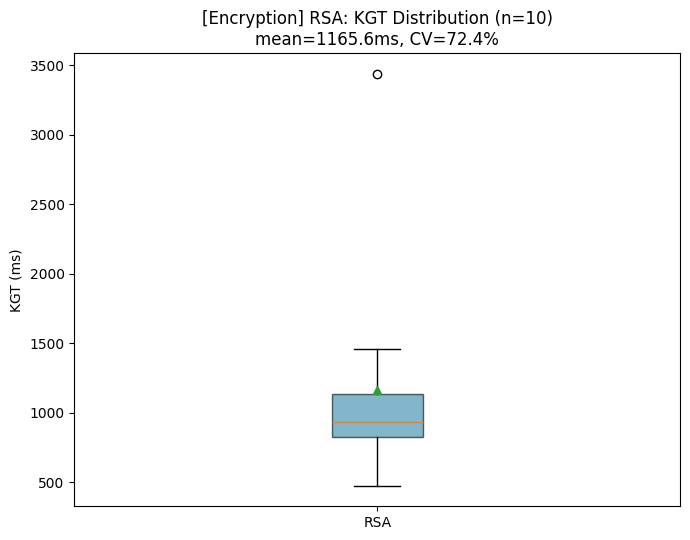

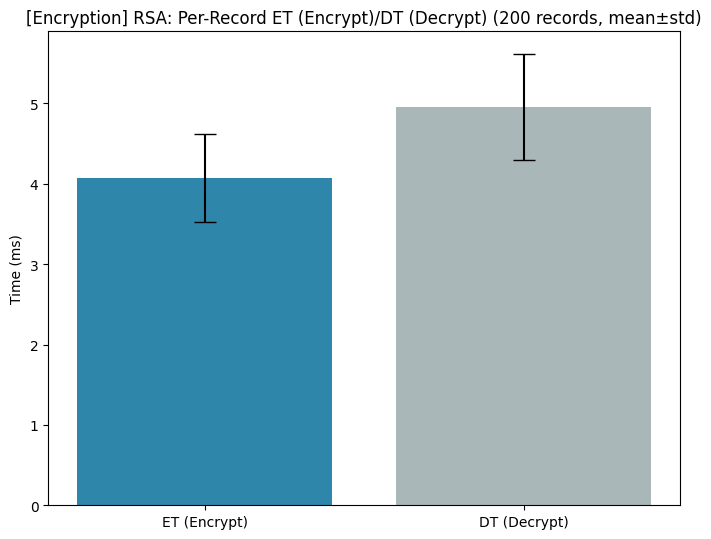

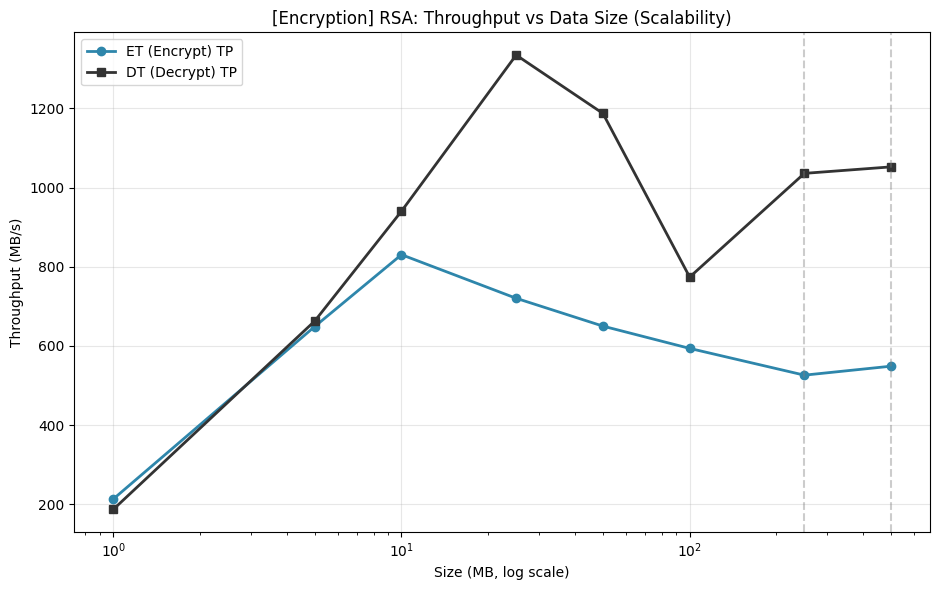

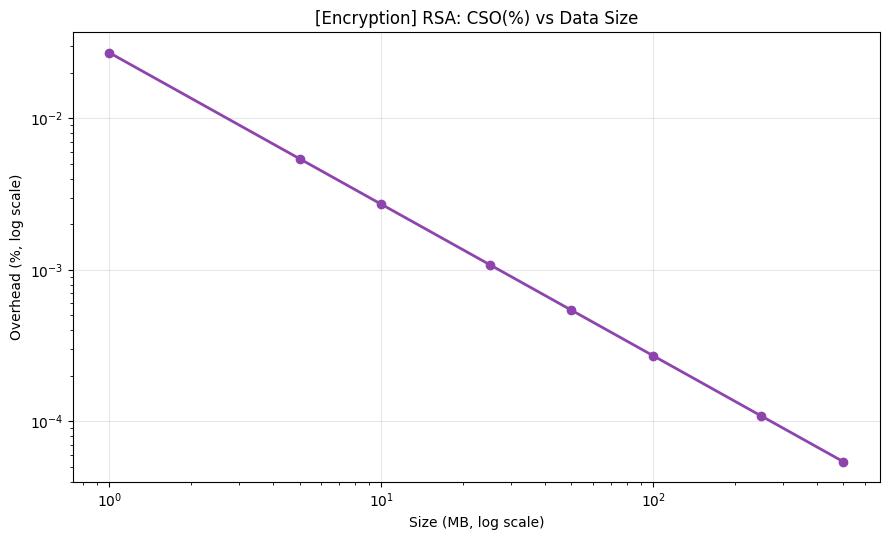

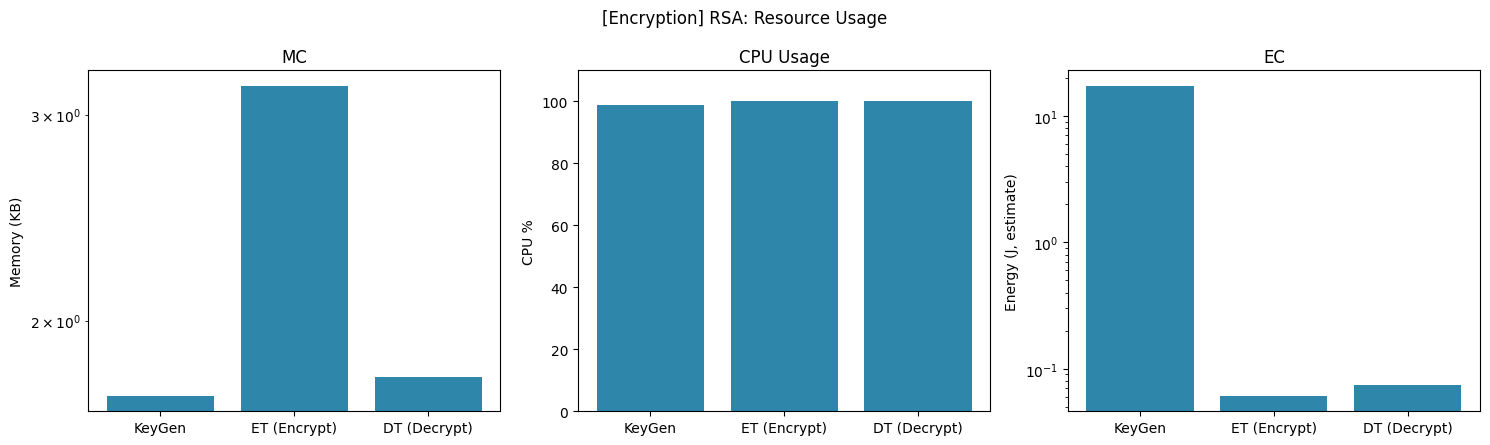

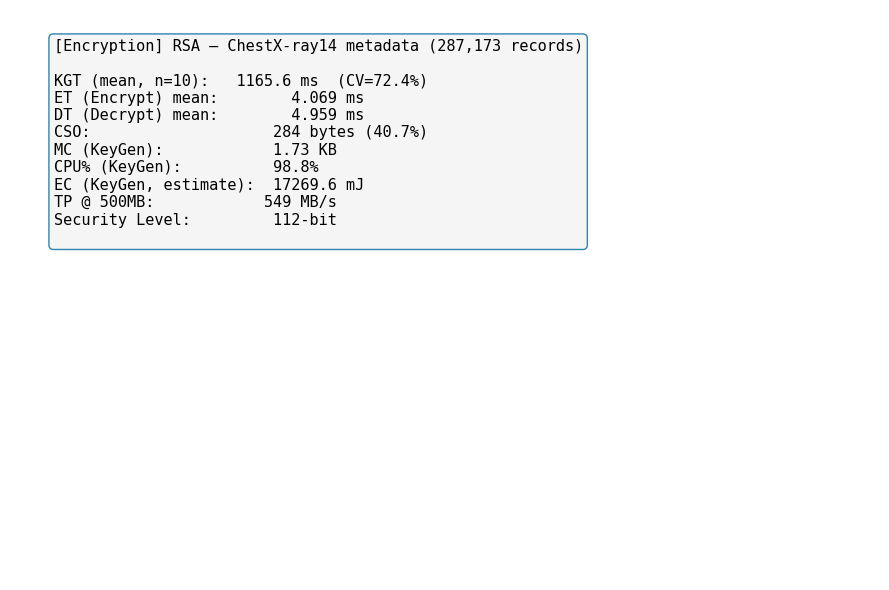

[Encryption] RSA: results + 6 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/Encryption/RSA/


In [13]:
enc_RSA = run_bulk_benchmark("Encryption", "RSA", ENCRYPTION_ALGORITHMS["RSA"], df, BASE_OUT_DIR)

## Run — Encryption: ECC


[Encryption] ECC: KGT, 10 runs
[Encryption] ECC: per-record ET/DT/CSO/MC/CPU/EC on 200 sampled real records
[Encryption] ECC: scalability (SC) + throughput (TP), sizes [1, 5, 10, 25, 50, 100, 250, 500] MB
  1MB (real): enc=6.9ms (144MB/s) dec=4.2ms (239MB/s)
  5MB (real): enc=9.2ms (543MB/s) dec=6.4ms (781MB/s)
  10MB (real): enc=13.9ms (721MB/s) dec=9.2ms (1092MB/s)
  25MB (real): enc=24.9ms (1003MB/s) dec=17.7ms (1416MB/s)
  50MB (real): enc=112.3ms (445MB/s) dec=55.7ms (898MB/s)
  100MB (real): enc=215.7ms (464MB/s) dec=108.6ms (921MB/s)
  250MB (tiled): enc=415.2ms (602MB/s) dec=241.4ms (1036MB/s)
  500MB (tiled): enc=923.1ms (542MB/s) dec=476.0ms (1050MB/s)


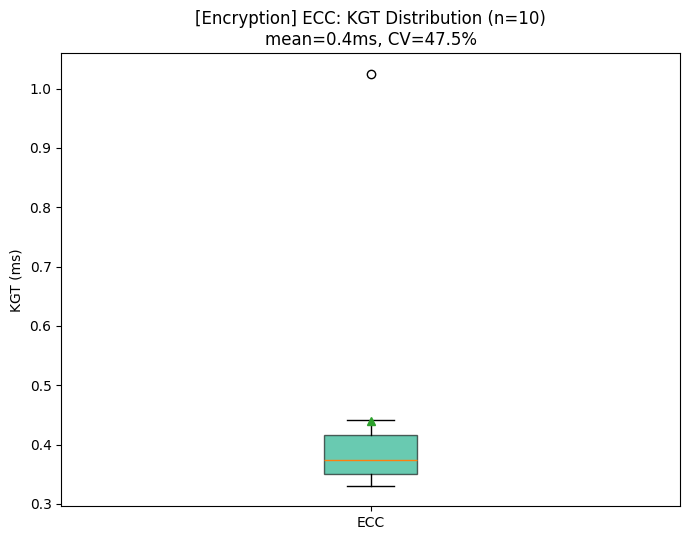

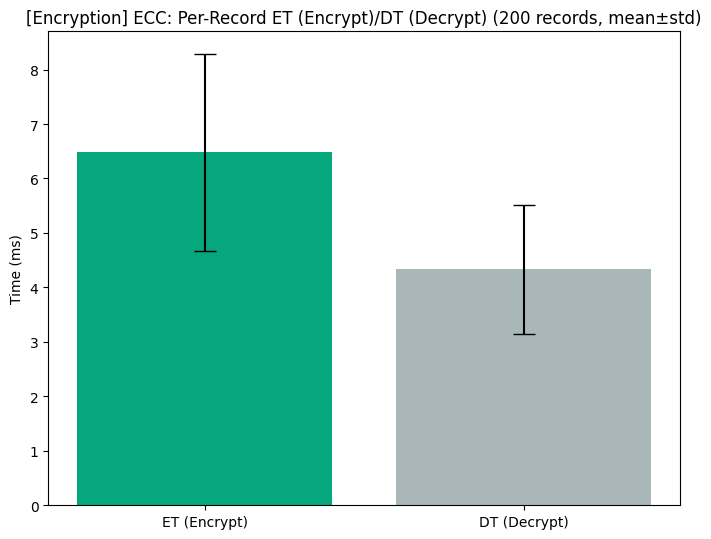

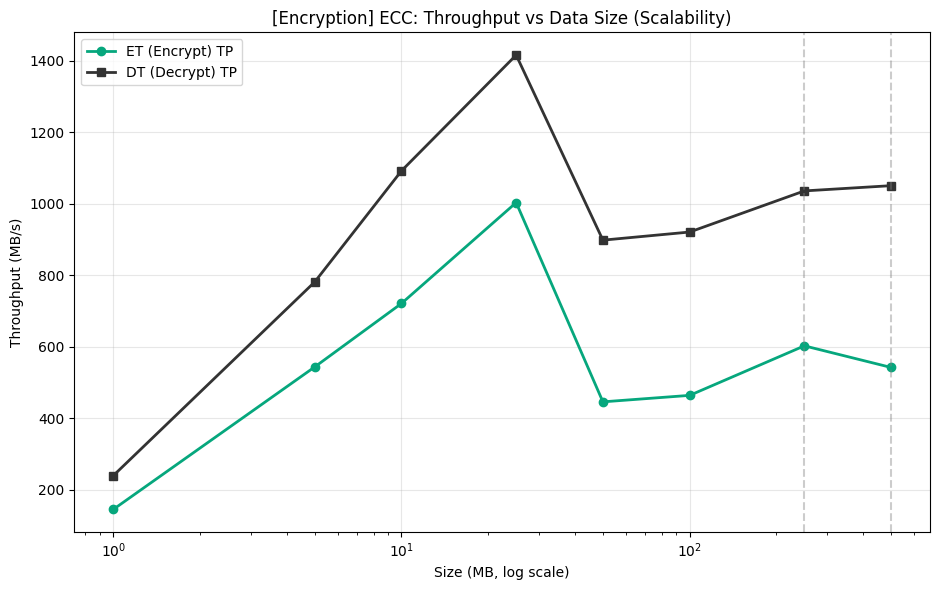

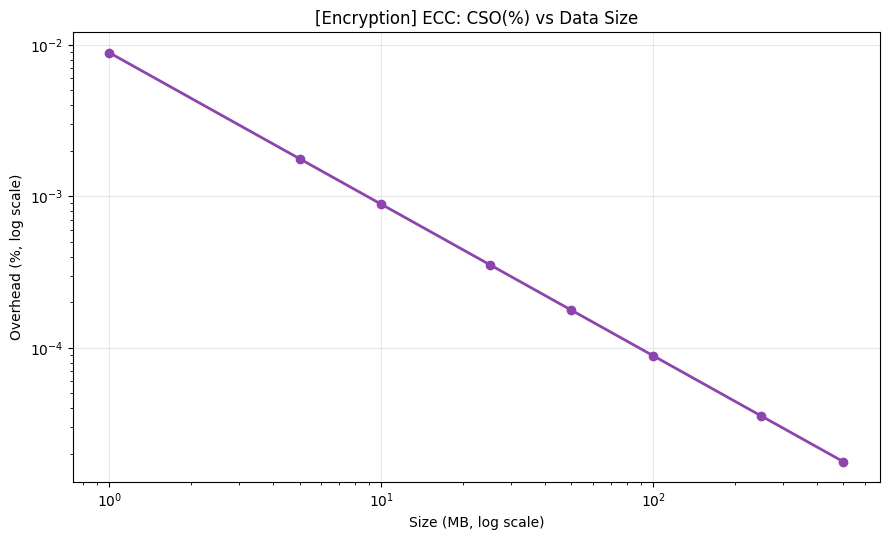

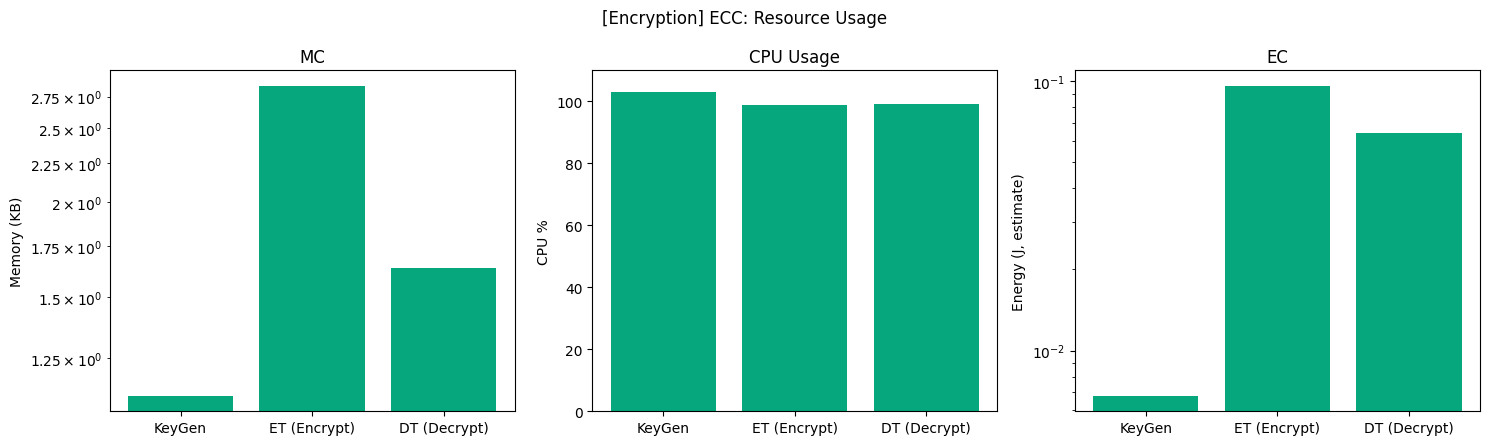

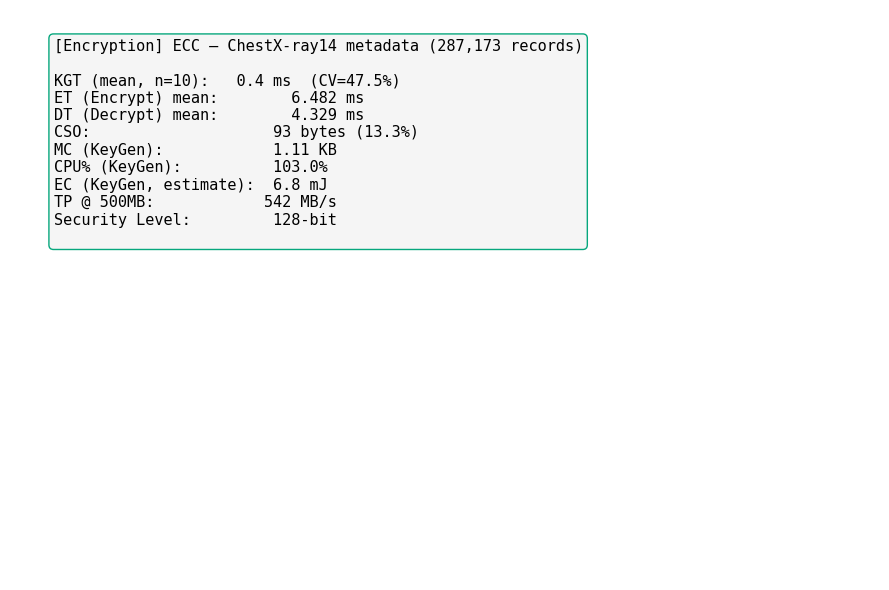

[Encryption] ECC: results + 6 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/Encryption/ECC/


In [14]:
enc_ECC = run_bulk_benchmark("Encryption", "ECC", ENCRYPTION_ALGORITHMS["ECC"], df, BASE_OUT_DIR)

## Run — Digital Signature: RSA (RSA-PSS)


[DigitalSignature] RSA: KGT, 10 runs
[DigitalSignature] RSA: per-record ET/DT/CSO/MC/CPU/EC on 200 sampled real records
[DigitalSignature] RSA: scalability (SC) + throughput (TP), sizes [1, 5, 10, 25, 50, 100, 250, 500] MB
  1MB (real): enc=21.3ms (47MB/s) dec=16.6ms (60MB/s)
  5MB (real): enc=64.4ms (78MB/s) dec=59.9ms (83MB/s)
  10MB (real): enc=116.7ms (86MB/s) dec=71.0ms (141MB/s)
  25MB (real): enc=161.2ms (155MB/s) dec=154.8ms (161MB/s)
  50MB (real): enc=342.4ms (146MB/s) dec=324.6ms (154MB/s)
  100MB (real): enc=859.2ms (116MB/s) dec=638.8ms (157MB/s)
  250MB (tiled): enc=2120.4ms (118MB/s) dec=1745.2ms (143MB/s)
  500MB (tiled): enc=3991.8ms (125MB/s) dec=3464.4ms (144MB/s)


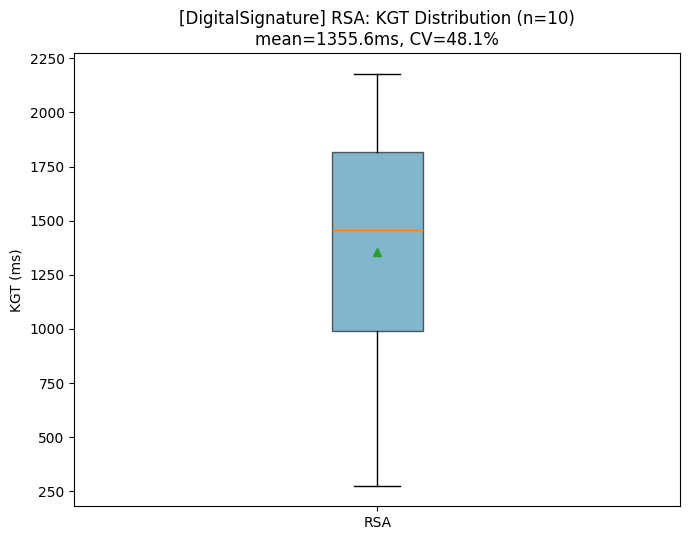

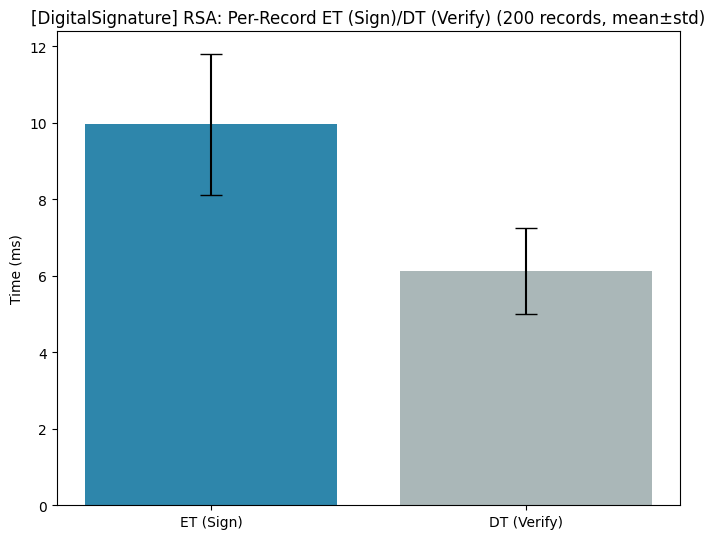

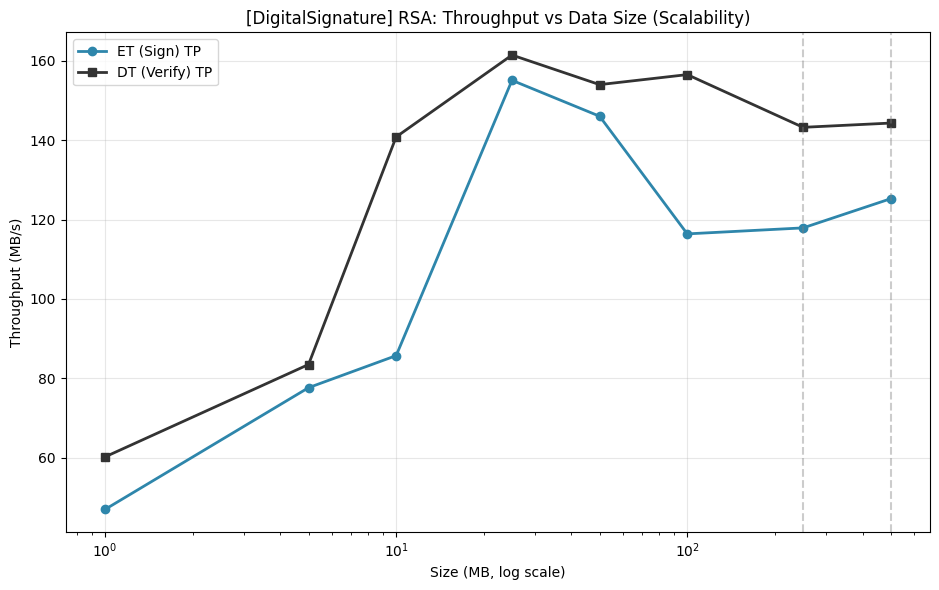

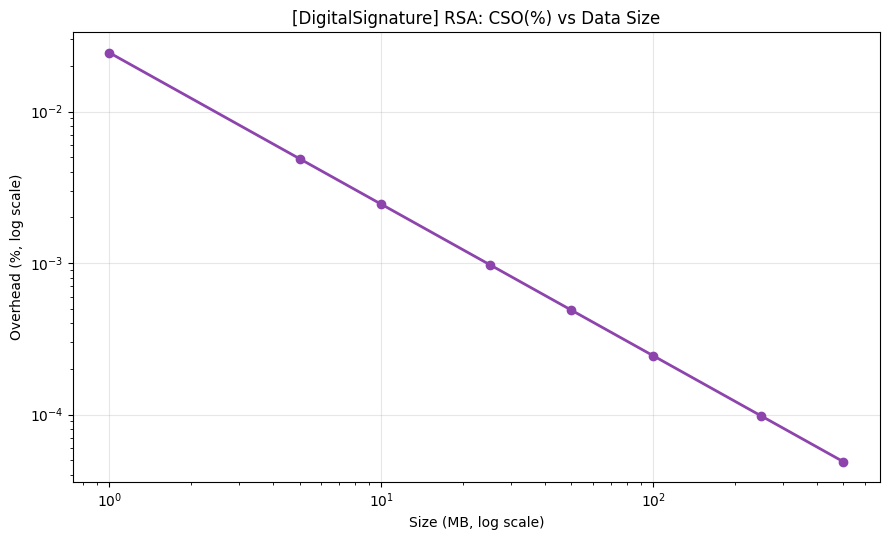

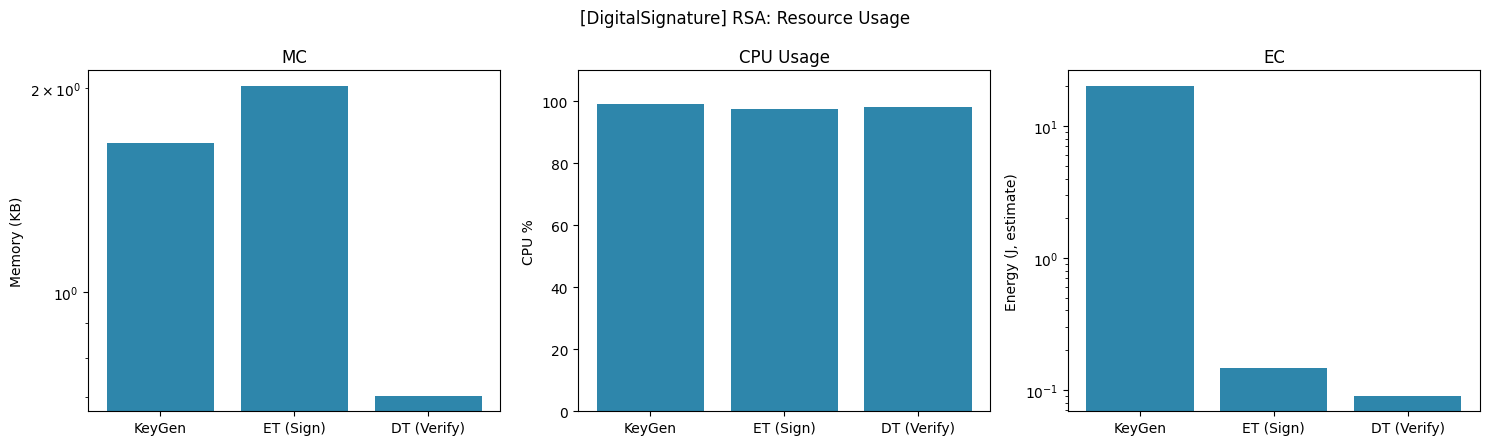

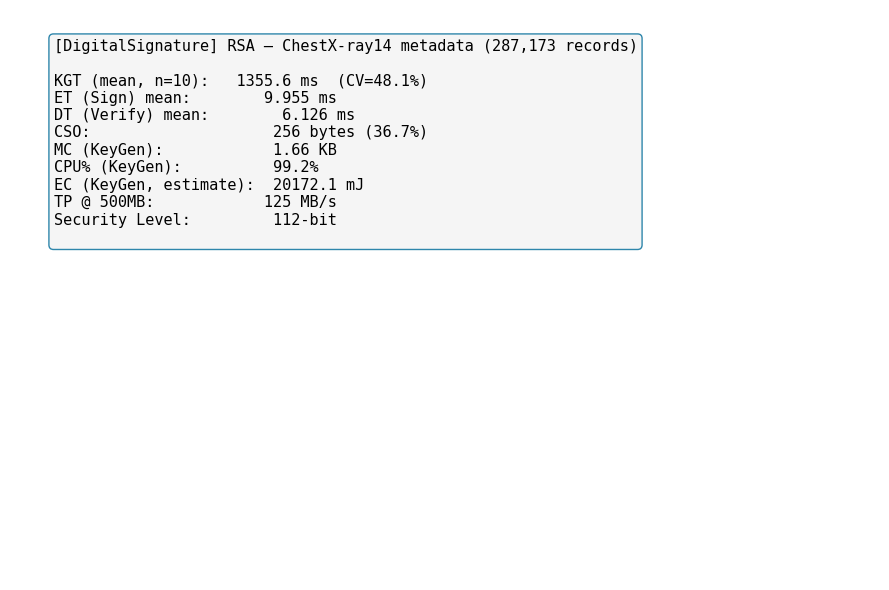

[DigitalSignature] RSA: results + 6 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/DigitalSignature/RSA/


In [15]:
sig_RSA = run_bulk_benchmark("DigitalSignature", "RSA", SIGNATURE_ALGORITHMS["RSA"], df, BASE_OUT_DIR)

## Run — Digital Signature: ECC (ECDSA)


[DigitalSignature] ECC: KGT, 10 runs
[DigitalSignature] ECC: per-record ET/DT/CSO/MC/CPU/EC on 200 sampled real records
[DigitalSignature] ECC: scalability (SC) + throughput (TP), sizes [1, 5, 10, 25, 50, 100, 250, 500] MB
  1MB (real): enc=9.3ms (107MB/s) dec=11.6ms (86MB/s)
  5MB (real): enc=36.1ms (138MB/s) dec=36.9ms (136MB/s)
  10MB (real): enc=105.3ms (95MB/s) dec=116.5ms (86MB/s)
  25MB (real): enc=280.2ms (89MB/s) dec=163.1ms (153MB/s)
  50MB (real): enc=343.4ms (146MB/s) dec=309.6ms (161MB/s)
  100MB (real): enc=879.7ms (114MB/s) dec=611.5ms (164MB/s)
  250MB (tiled): enc=2071.0ms (121MB/s) dec=1751.4ms (143MB/s)
  500MB (tiled): enc=3879.9ms (129MB/s) dec=3619.8ms (138MB/s)


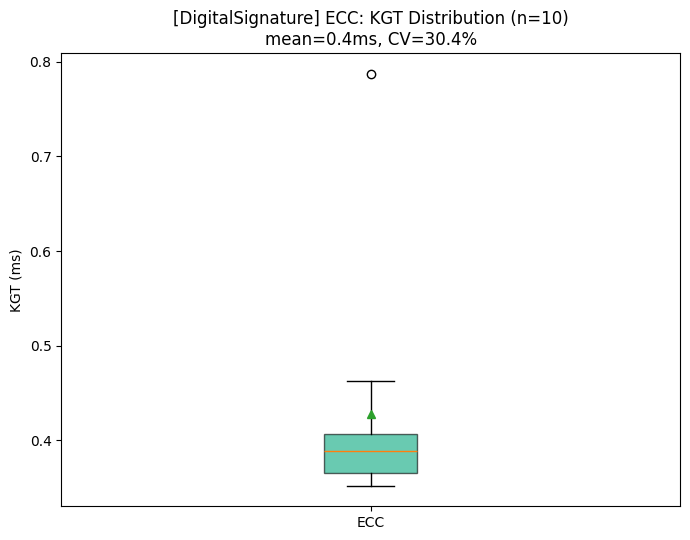

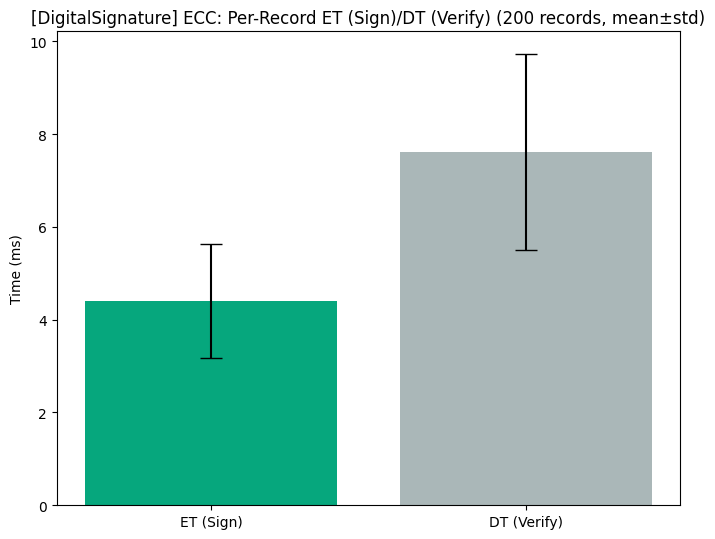

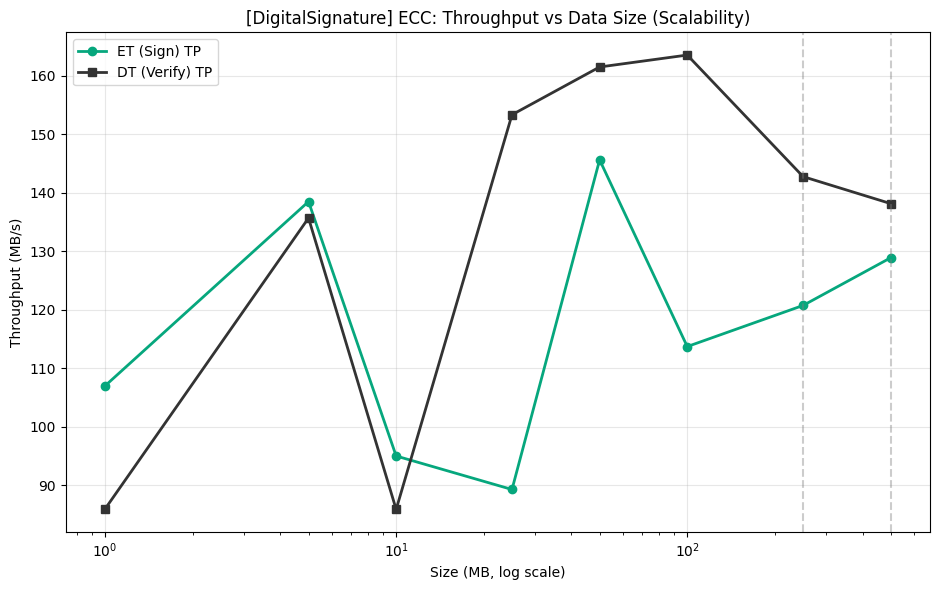

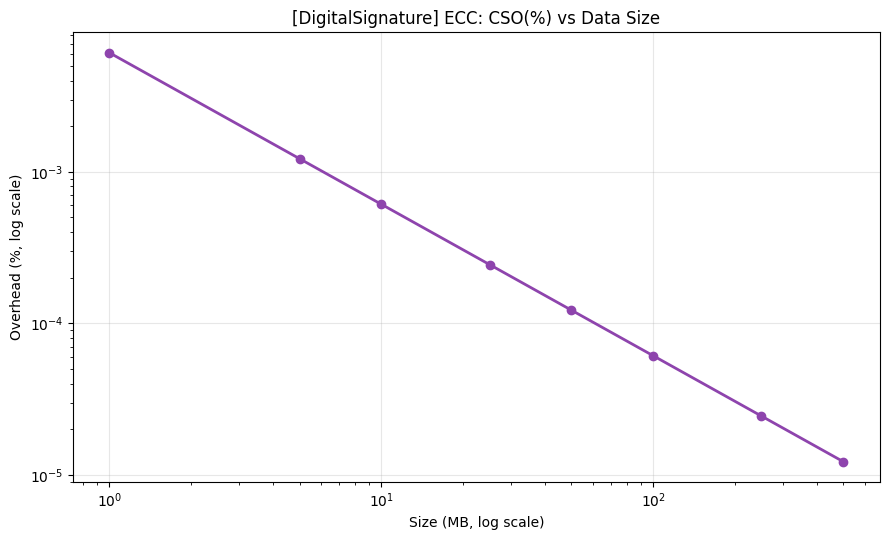

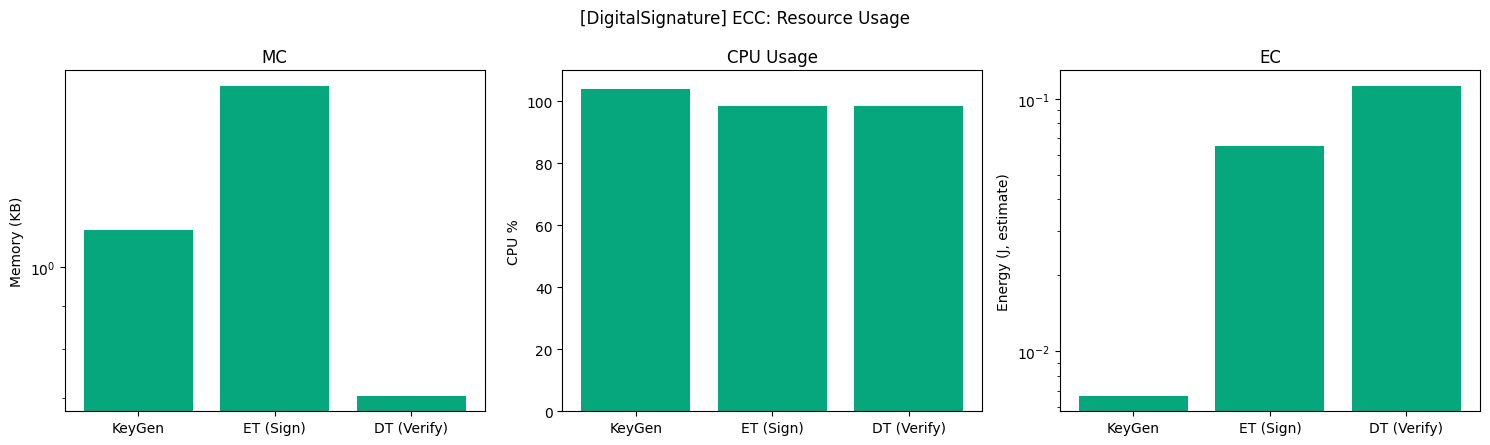

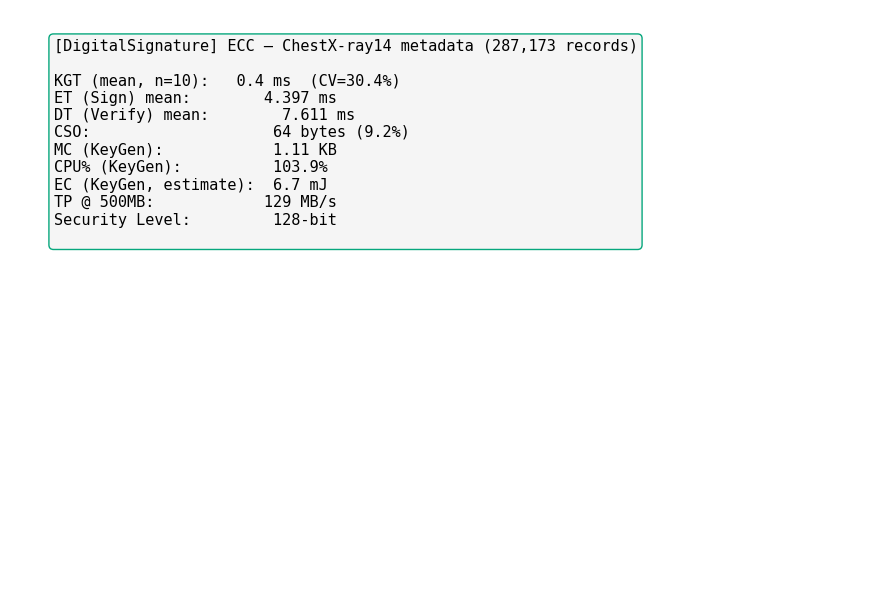

[DigitalSignature] ECC: results + 6 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/DigitalSignature/ECC/


In [16]:
sig_ECC = run_bulk_benchmark("DigitalSignature", "ECC", SIGNATURE_ALGORITHMS["ECC"], df, BASE_OUT_DIR)

## Run — Digital Signature: DSA


[DigitalSignature] DSA: KGT, 10 runs
[DigitalSignature] DSA: per-record ET/DT/CSO/MC/CPU/EC on 200 sampled real records
[DigitalSignature] DSA: scalability (SC) + throughput (TP), sizes [1, 5, 10, 25, 50, 100, 250, 500] MB
  1MB (real): enc=9.3ms (108MB/s) dec=9.0ms (111MB/s)
  5MB (real): enc=34.5ms (145MB/s) dec=34.5ms (145MB/s)
  10MB (real): enc=66.5ms (150MB/s) dec=63.5ms (157MB/s)
  25MB (real): enc=157.5ms (159MB/s) dec=152.4ms (164MB/s)
  50MB (real): enc=484.7ms (103MB/s) dec=359.6ms (139MB/s)
  100MB (real): enc=679.7ms (147MB/s) dec=822.3ms (122MB/s)
  250MB (tiled): enc=1889.2ms (132MB/s) dec=1727.1ms (145MB/s)
  500MB (tiled): enc=3952.0ms (127MB/s) dec=3473.3ms (144MB/s)


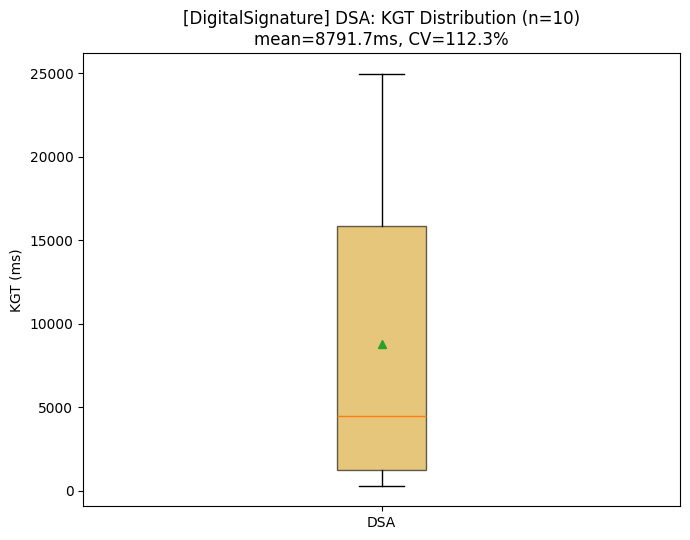

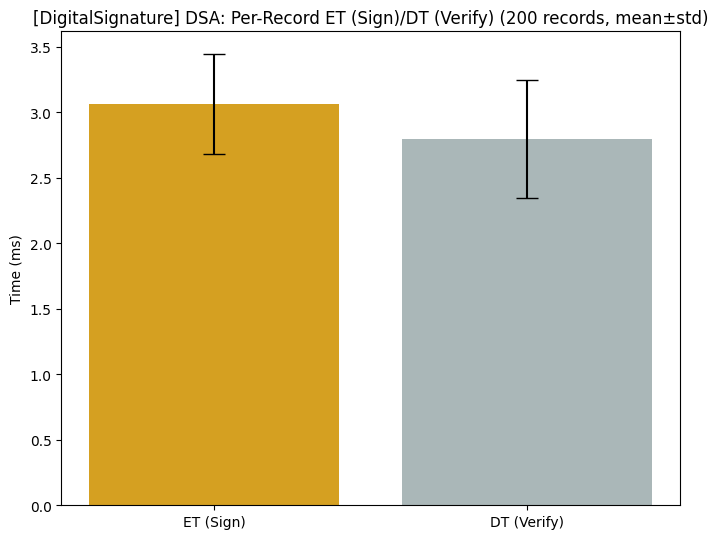

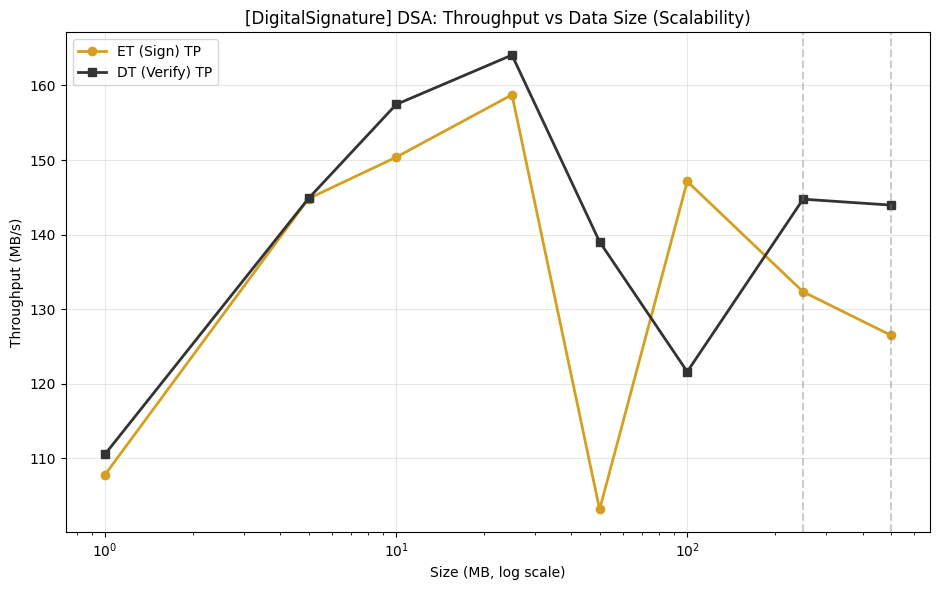

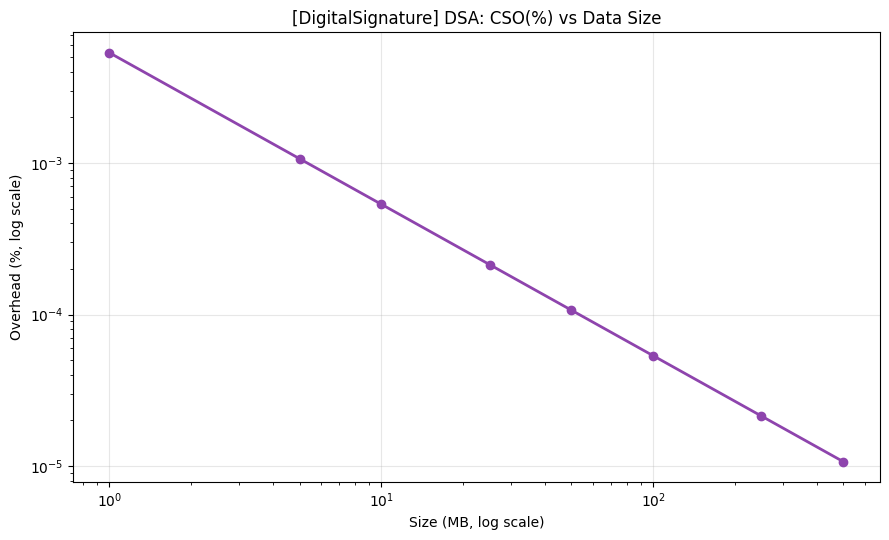

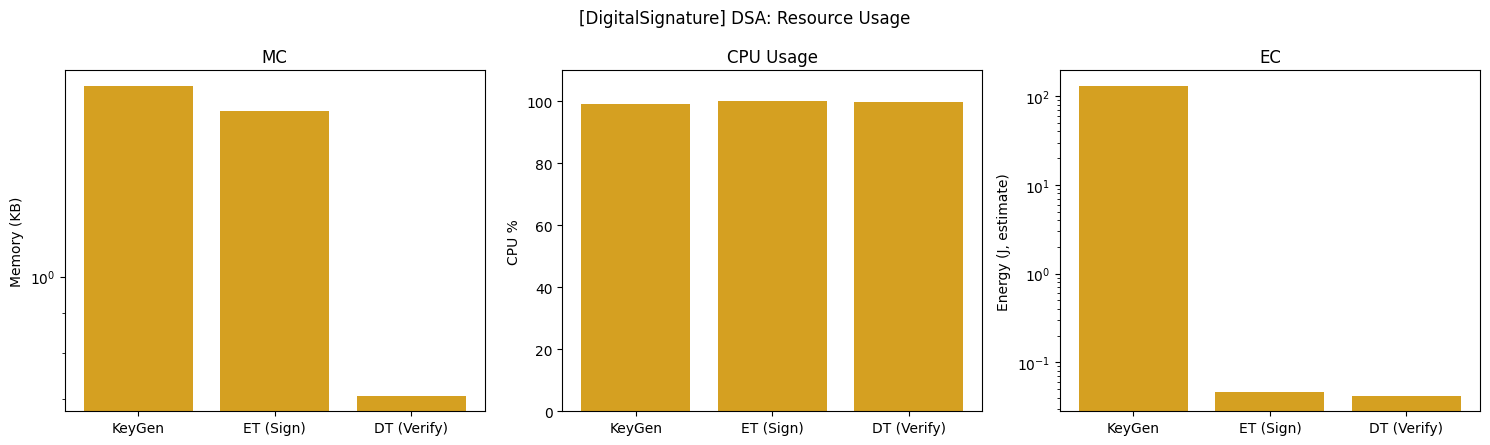

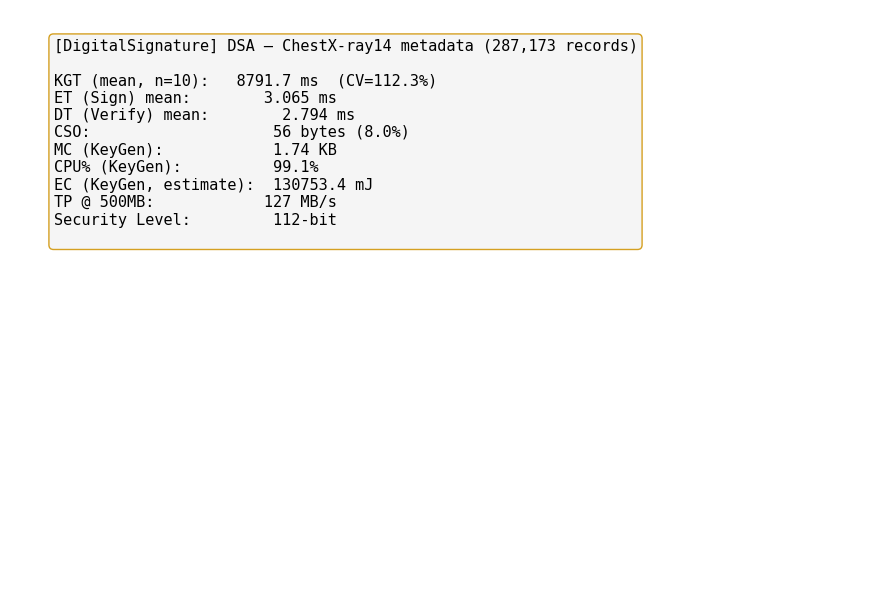

[DigitalSignature] DSA: results + 6 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/DigitalSignature/DSA/


In [17]:
sig_DSA = run_bulk_benchmark("DigitalSignature", "DSA", SIGNATURE_ALGORITHMS["DSA"], df, BASE_OUT_DIR)

## Run — Key Exchange: ECC (ECDH)


[KeyExchange] ECC: KGT, 10 runs
[KeyExchange] ECC: ET (initiator)/DT (responder) over 200 independent exchanges


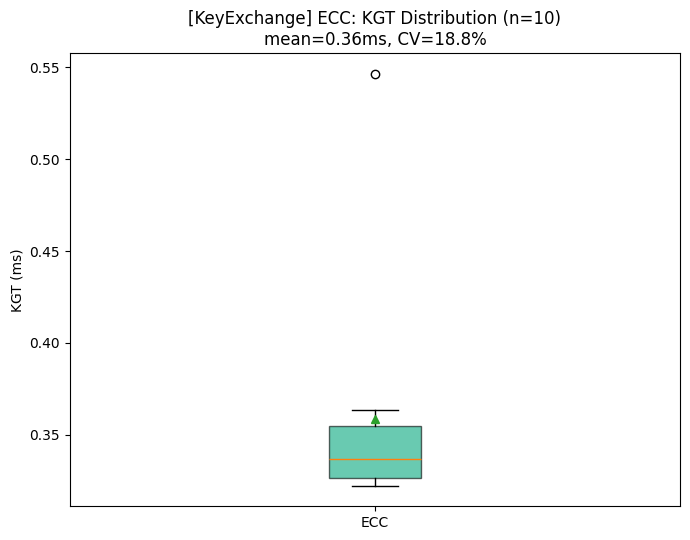

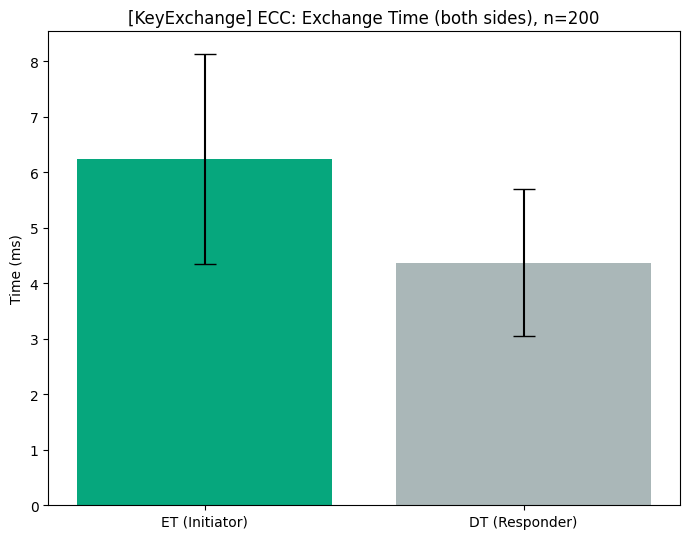

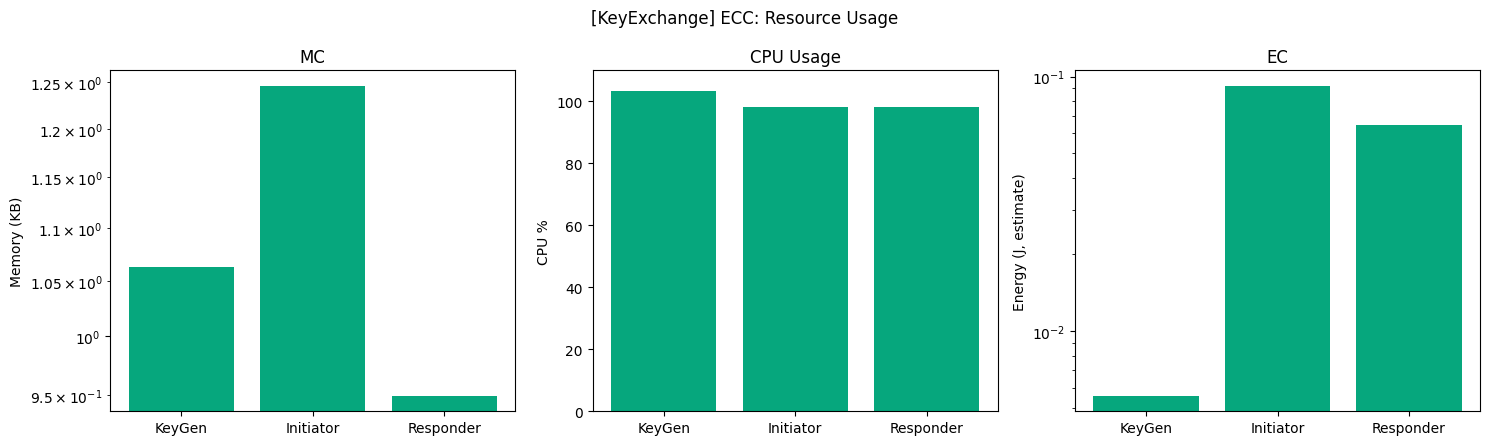

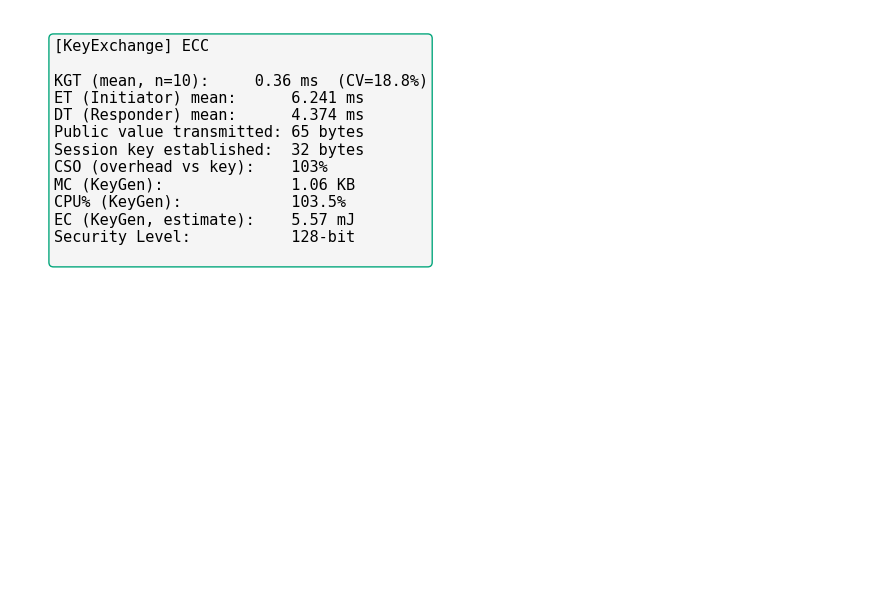

[KeyExchange] ECC: results + 4 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/KeyExchange/ECC/


In [18]:
kex_ECC = run_keyexchange_benchmark("ECC", KEYEXCHANGE_ALGORITHMS["ECC"], df, BASE_OUT_DIR)

## Run — Key Exchange: DH


[KeyExchange] DH: KGT, 10 runs
[KeyExchange] DH: ET (initiator)/DT (responder) over 200 independent exchanges


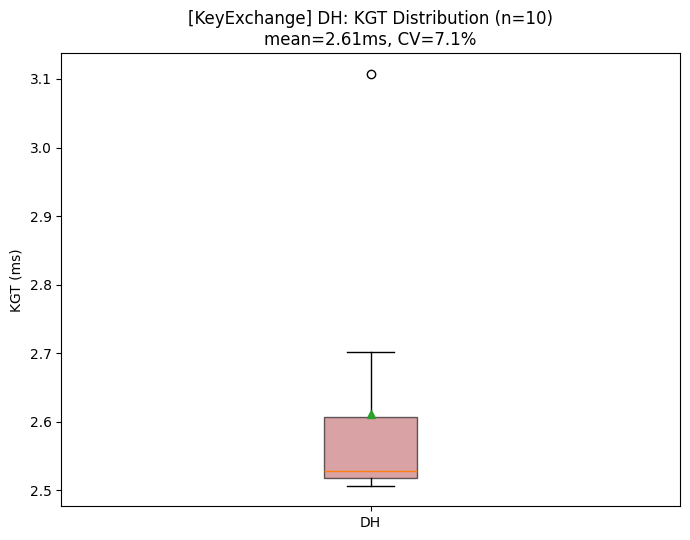

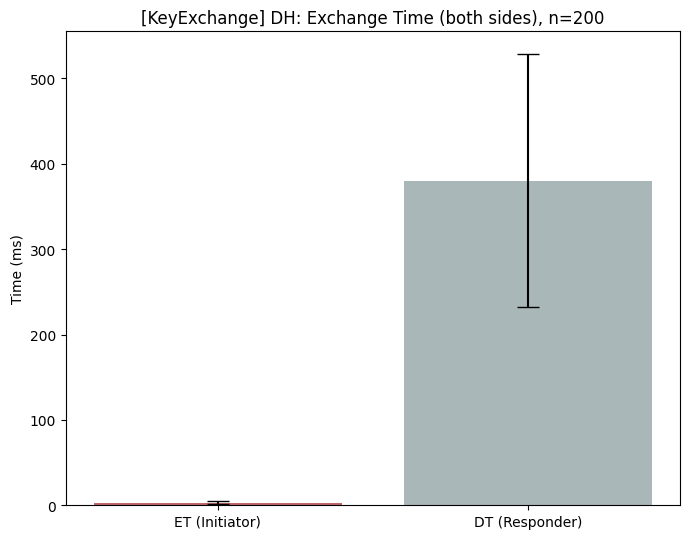

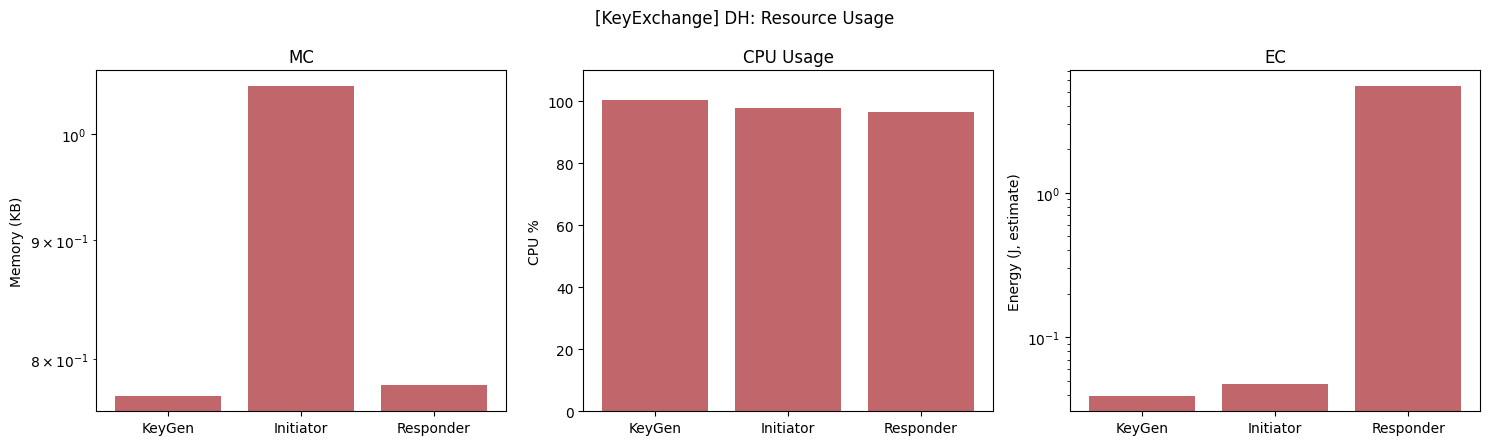

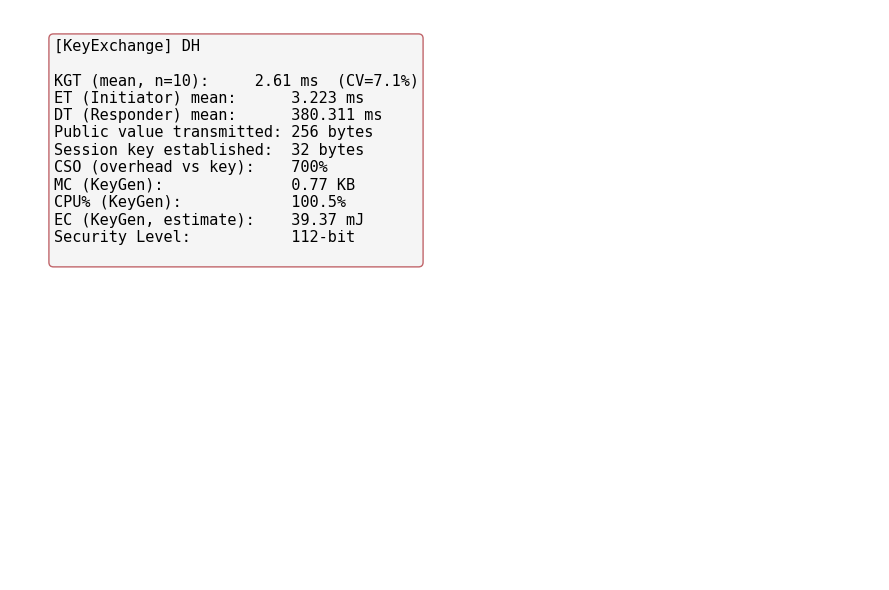

[KeyExchange] DH: results + 4 charts saved to /content/drive/MyDrive/MIT SuperCloud Dataset/PKC_Results/KeyExchange/DH/


In [19]:
kex_DH = run_keyexchange_benchmark("DH", KEYEXCHANGE_ALGORITHMS["DH"], df, BASE_OUT_DIR)

# Within-Aspect Comparison Functions

In [20]:
def compare_within_aspect(aspect, results_dict, out_base_dir, is_keyexchange=False):
    """Bar-chart + ranked comparison of all algorithms tested for one aspect.
    Adds: CPU% comparison, TP comparison, composite tradeoff radar, and (for
    aspects with a bulk-data scalability sweep) overlaid Scalability/Throughput
    and CSO(%) scaling curves across all algorithms in the aspect."""
    out_dir = os.path.join(out_base_dir, aspect, "Comparison")
    os.makedirs(out_dir, exist_ok=True)
    names = list(results_dict.keys())
    C = {"RSA": "#2E86AB", "ECC": "#06A77D", "DH": "#C1666B", "DSA": "#D5A021"}

    rows = []
    for n in names:
        r = results_dict[n]
        if is_keyexchange:
            rows.append({
                "Algorithm": n, "KGT_mean_ms": r["kgt"]["mean"], "KGT_CV_%": r["kgt"]["cv_pct"],
                "ET_mean_ms": r["et_initiator"]["mean"], "DT_mean_ms": r["dt_responder"]["mean"],
                "CSO_%": r["cso"]["mean_pct"], "MC_KeyGen_KB": r["kgt"]["mc_bar_kb"],
                "CPU%_KeyGen": r["kgt"]["cpu_pct"], "EC_KeyGen_mJ": r["kgt"]["energy_j"] * 1000,
                "Security_bits": r["security_bits"],
            })
        else:
            rows.append({
                "Algorithm": n, "KGT_mean_ms": r["kgt"]["mean"], "KGT_CV_%": r["kgt"]["cv_pct"],
                "ET_mean_ms": r["et"]["mean"], "DT_mean_ms": r["dt"]["mean"],
                "CSO_%": r["cso"]["mean_pct"], "MC_KeyGen_KB": r["kgt"]["mc_bar_kb"],
                "CPU%_KeyGen": r["kgt"]["cpu_pct"], "EC_KeyGen_mJ": r["kgt"]["energy_j"] * 1000,
                "TP_maxsize_MBps": r["scalability"][-1]["throughput_encrypt_mbps"],
                "Security_bits": r["security_bits"],
            })
    comp_df = pd.DataFrame(rows)

    baseline = max(comp_df["KGT_mean_ms"]); baseline_name = comp_df.loc[comp_df["KGT_mean_ms"].idxmax(), "Algorithm"]
    comp_df[f"Speedup_vs_{baseline_name}"] = baseline / comp_df["KGT_mean_ms"]

    def norm_lower(vals):
        lo, hi = min(vals), max(vals)
        return [1.0 if hi == lo else 1.0 - (v - lo) / (hi - lo) for v in vals]
    def norm_higher(vals):
        lo, hi = min(vals), max(vals)
        return [1.0 if hi == lo else (v - lo) / (hi - lo) for v in vals]

    n_kgt = norm_lower(comp_df["KGT_mean_ms"].tolist())
    n_et = norm_lower(comp_df["ET_mean_ms"].tolist())
    n_cso = norm_lower(comp_df["CSO_%"].tolist())
    n_mc = norm_lower(comp_df["MC_KeyGen_KB"].tolist())
    n_ec = norm_lower(comp_df["EC_KeyGen_mJ"].tolist())
    n_sec = norm_higher(comp_df["Security_bits"].tolist())
    weights = {"kgt": 0.25, "et": 0.20, "cso": 0.15, "mc": 0.15, "ec": 0.10, "sec": 0.15}
    scores = {n: round(100 * (weights["kgt"]*n_kgt[i] + weights["et"]*n_et[i] + weights["cso"]*n_cso[i] +
                               weights["mc"]*n_mc[i] + weights["ec"]*n_ec[i] + weights["sec"]*n_sec[i]), 1)
              for i, n in enumerate(names)}
    ranked = sorted(scores.items(), key=lambda x: -x[1])
    comp_df["Composite_Score"] = comp_df["Algorithm"].map(scores)
    comp_df.to_csv(os.path.join(out_dir, f"{aspect}_comparison_table.csv"), index=False)
    with open(os.path.join(out_dir, f"{aspect}_comparison_table.json"), "w") as f:
        json.dump(rows, f, indent=2, default=str)

    def bar(metric, title, ylabel, log=False, fname="x.png"):
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
        vals = comp_df[metric].tolist()
        ax.bar(names, vals, color=[C[n] for n in names])
        if log: ax.set_yscale("log")
        ax.set_ylabel(ylabel); ax.set_title(title)
        for i, v in enumerate(vals):
            ax.annotate(f"{v:.2f}", (i, v), ha='center', va='bottom', fontsize=9)
        plt.tight_layout(); fig.savefig(os.path.join(out_dir, fname), dpi=150); plt.show()

    bar("KGT_mean_ms", f"[{aspect}] KGT Comparison", "Time (ms, log)", True, "1_kgt.png")
    bar("ET_mean_ms", f"[{aspect}] ET Comparison", "Time (ms)", False, "2_et.png")
    bar("DT_mean_ms", f"[{aspect}] DT Comparison", "Time (ms)", False, "3_dt.png")
    bar("CSO_%", f"[{aspect}] CSO(%) Comparison", "Overhead (%)", False, "4_cso.png")
    bar("MC_KeyGen_KB", f"[{aspect}] Memory (MC) Comparison", "Memory (KB, log)", True, "5_mc.png")
    bar("CPU%_KeyGen", f"[{aspect}] CPU Utilization (CPU) Comparison", "CPU (%)", False, "6_cpu.png")
    bar("EC_KeyGen_mJ", f"[{aspect}] Energy (EC) Comparison", "Energy (mJ, log)", True, "7_ec.png")
    if not is_keyexchange:
        bar("TP_maxsize_MBps", f"[{aspect}] Throughput (TP) @ {SCALABILITY_SIZES_MB[-1]}MB Comparison",
            "Throughput (MB/s, log)", True, "8_tp.png")
    bar("Security_bits", f"[{aspect}] Security Level Comparison", "Bits (NIST SP 800-57)", False, "9_security.png")
    bar(f"Speedup_vs_{baseline_name}", f"[{aspect}] Speedup (vs Slowest: {baseline_name})", "Speedup (x)", True, "10_speedup.png")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh([r[0] for r in ranked], [r[1] for r in ranked], color=[C[r[0]] for r in ranked])
    ax.set_xlabel("Composite Score (0-100)"); ax.set_xlim(0, 100)
    ax.set_title(f"[{aspect}] Overall Ranking")
    for i, r in enumerate(ranked): ax.annotate(f"{r[1]}", (r[1]+1, i), va='center')
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, "11_ranking.png"), dpi=150); plt.show()

    # ---------------- Composite Tradeoff Radar ----------------
    categories = ["KGT\n(speed)", "ET\n(speed)", "CSO\n(compactness)", "Memory\nEfficiency",
                  "Energy\nEfficiency", "Security\nLevel"]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist(); angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
    for i, n in enumerate(names):
        vals = [n_kgt[i], n_et[i], n_cso[i], n_mc[i], n_ec[i], n_sec[i]]; vals += vals[:1]
        ax.plot(angles, vals, label=n, color=C[n], linewidth=2)
        ax.fill(angles, vals, color=C[n], alpha=0.08)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f"[{aspect}] Composite Tradeoff Radar\n(1.0 = best in that category)", pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, "12_radar_tradeoff.png"), dpi=150); plt.show()

    # ---------------- Scalability (SC) + CSO(%) overlay curves, all algorithms ----------------
    # Only meaningful for aspects with a bulk-data scalability sweep (Encryption, Digital Signature).
    # Key Exchange has no growing payload to scale.
    if not is_keyexchange:
        fig, ax = plt.subplots(figsize=(10, 6.5))
        for n in names:
            scal = results_dict[n]["scalability"]
            sizes = [s["size_mb"] for s in scal]
            tp = [s["throughput_encrypt_mbps"] for s in scal]
            ax.plot(sizes, tp, marker='o', label=n, color=C[n], linewidth=2)
        ax.set_xscale("log")
        ax.set_xlabel("Data Size (MB, log scale)"); ax.set_ylabel("Encrypt/Sign Throughput (MB/s)")
        ax.set_title(f"[{aspect}] Scalability (SC): Throughput vs Data Size \u2014 All Algorithms")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); fig.savefig(os.path.join(out_dir, "13_scalability_all.png"), dpi=150); plt.show()

        fig, ax = plt.subplots(figsize=(10, 6.5))
        for n in names:
            scal = results_dict[n]["scalability"]
            sizes = [s["size_mb"] for s in scal]
            ov = [s["overhead_pct"] for s in scal]
            ax.plot(sizes, ov, marker='o', label=n, color=C[n], linewidth=2)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("Data Size (MB, log scale)"); ax.set_ylabel("Overhead (%, log scale)")
        ax.set_title(f"[{aspect}] Ciphertext/Signature Overhead Scaling \u2014 All Algorithms")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); fig.savefig(os.path.join(out_dir, "14_cso_scaling_all.png"), dpi=150); plt.show()

    print(f"\n[{aspect}] Ranking: " + ", ".join([f"{n}={s}" for n, s in ranked]))
    return comp_df, ranked


def overall_summary(enc_ranked, sig_ranked, kex_ranked, out_base_dir):
    """One consolidated view across all three PKC aspects."""
    out_dir = os.path.join(out_base_dir, "OverallSummary")
    os.makedirs(out_dir, exist_ok=True)
    C = {"RSA": "#2E86AB", "ECC": "#06A77D", "DH": "#C1666B", "DSA": "#D5A021"}

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, (title, ranked) in zip(axes, [("Encryption", enc_ranked), ("Digital Signature", sig_ranked),
                                            ("Key Exchange", kex_ranked)]):
        names = [r[0] for r in ranked]; vals = [r[1] for r in ranked]
        ax.barh(names, vals, color=[C[n] for n in names])
        ax.set_xlim(0, 100); ax.set_title(title); ax.set_xlabel("Composite Score")
        for i, v in enumerate(vals): ax.annotate(f"{v}", (v+1, i), va='center')
    plt.suptitle("Overall PKC Evaluation \u2014 Best Algorithm per Aspect")
    plt.tight_layout(); fig.savefig(os.path.join(out_dir, "overall_summary.png"), dpi=150); plt.show()

    print("\n=== FINAL SUMMARY: Best algorithm per PKC aspect ===")
    print(f"Encryption:        {enc_ranked[0][0]} (score {enc_ranked[0][1]})")
    print(f"Digital Signature: {sig_ranked[0][0]} (score {sig_ranked[0][1]})")
    print(f"Key Exchange:      {kex_ranked[0][0]} (score {kex_ranked[0][1]})")


## Compare: Encryption (RSA vs ECC)

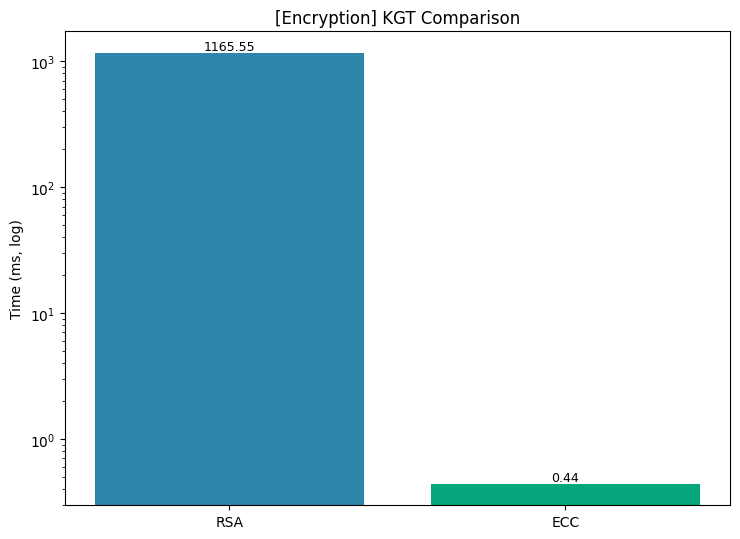

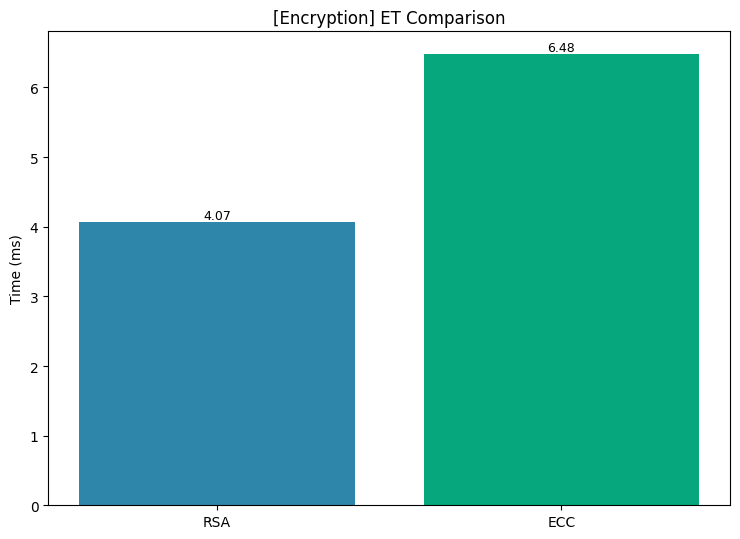

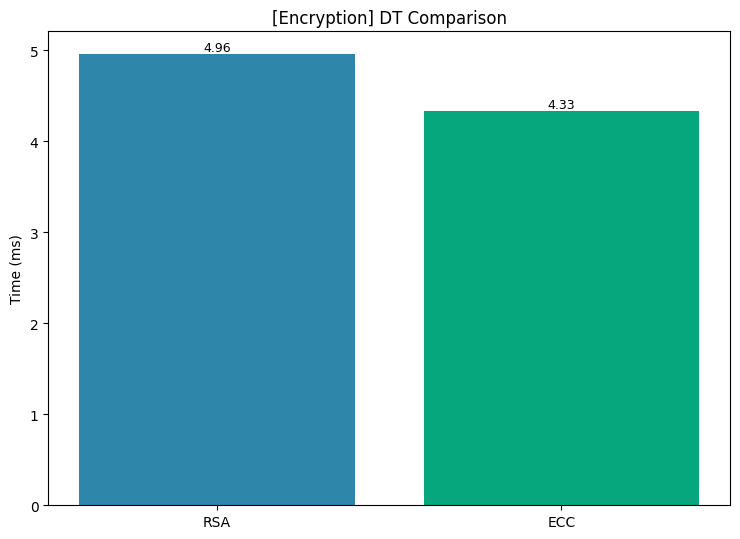

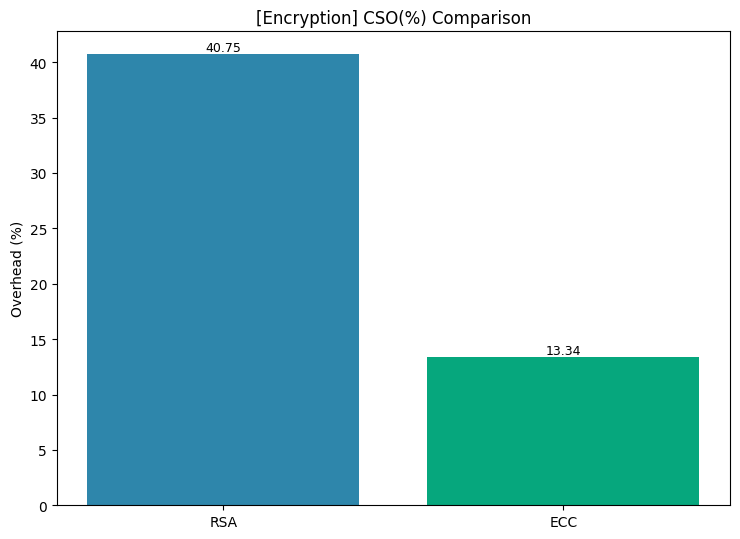

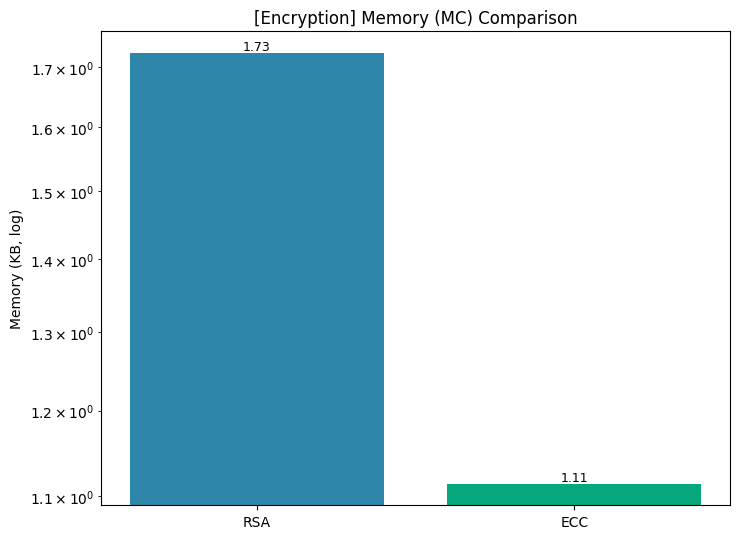

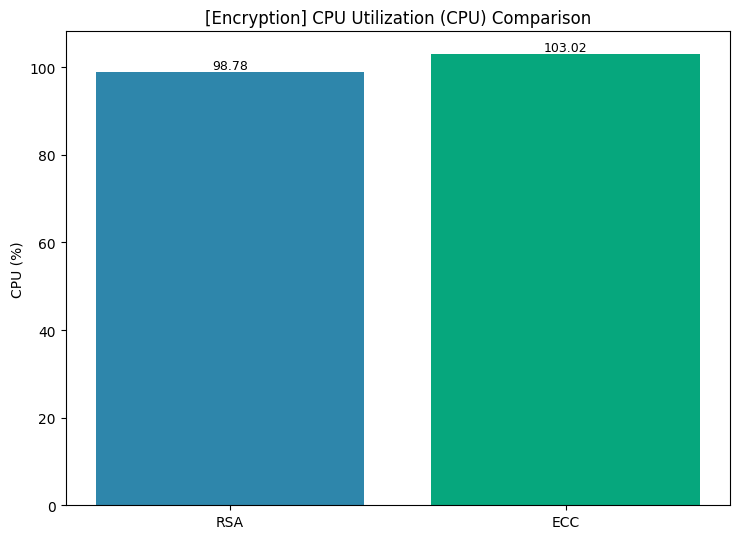

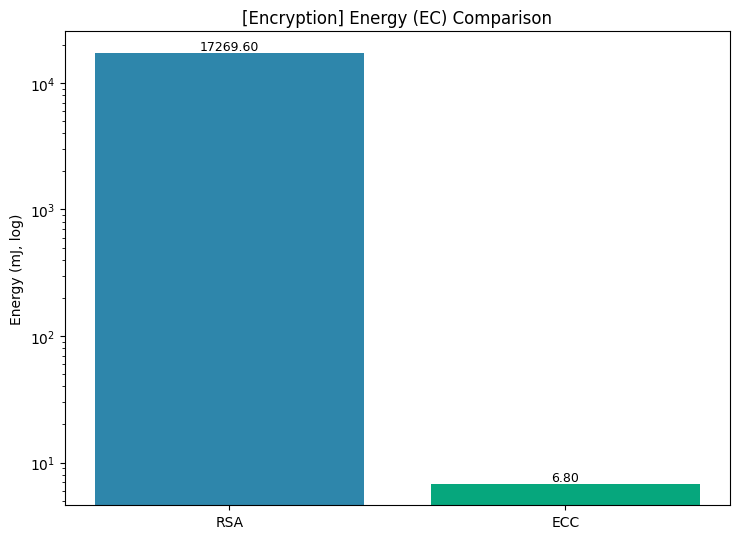

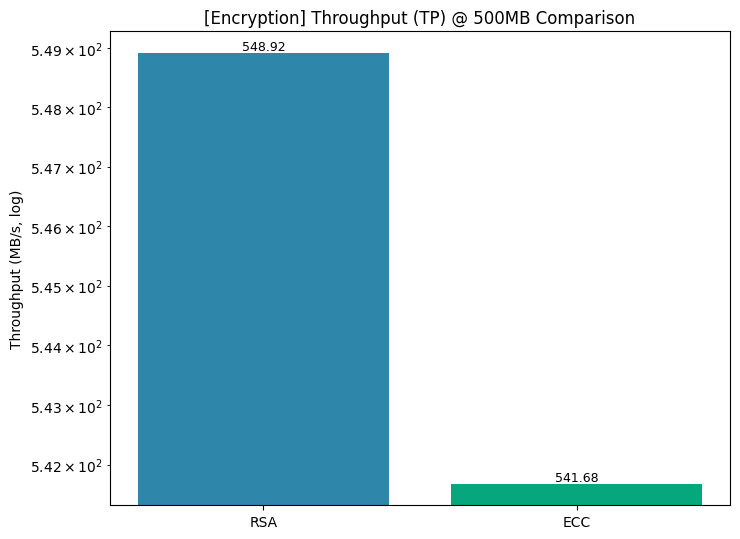

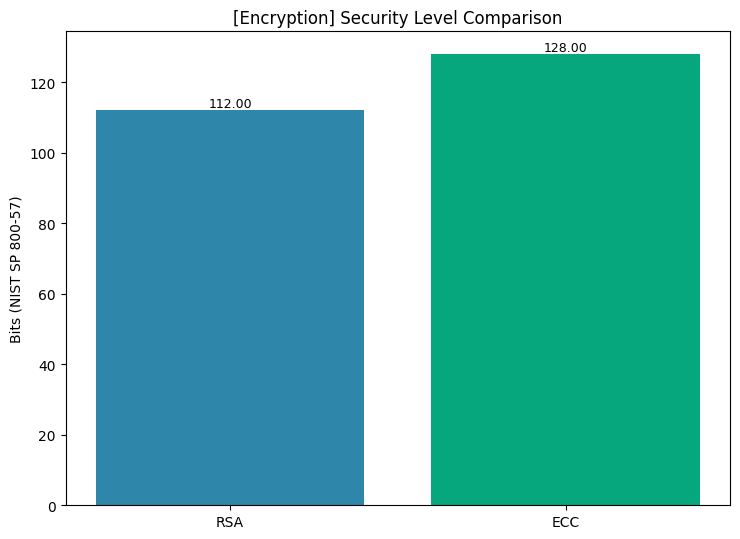

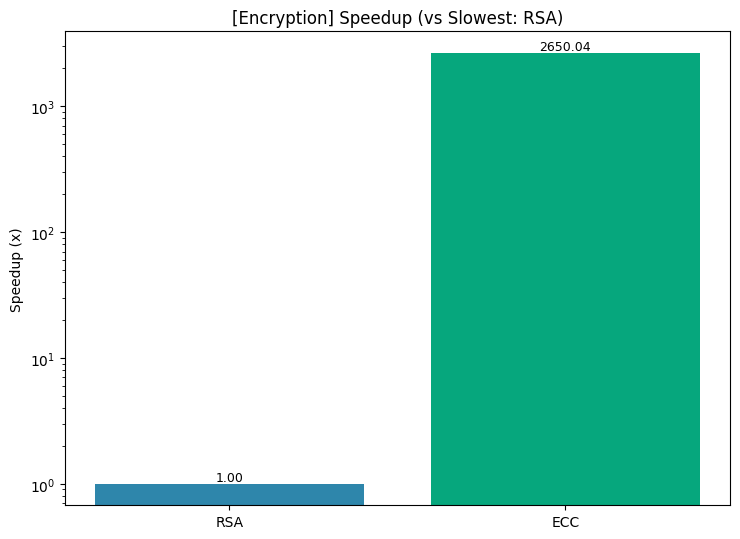

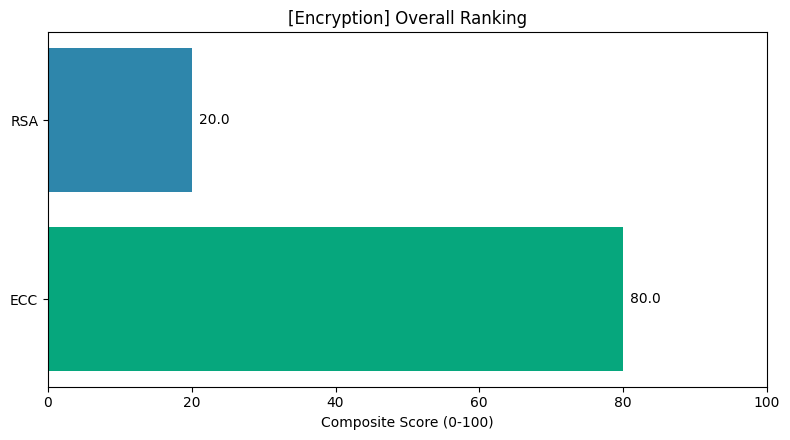

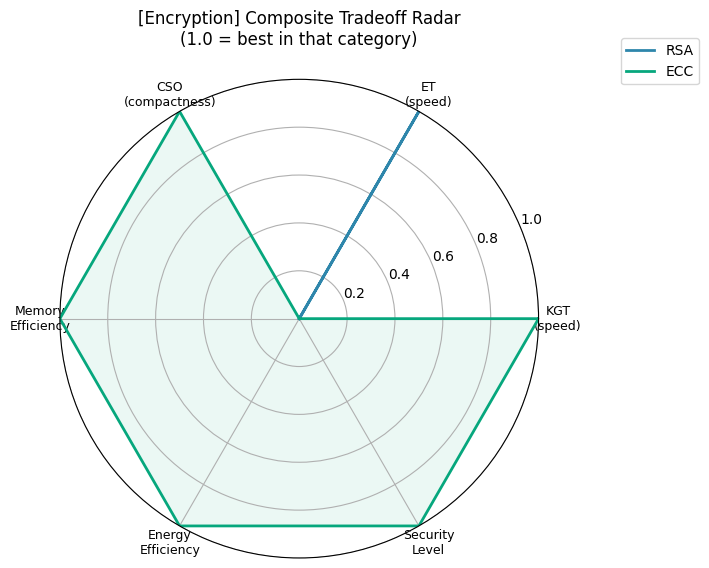

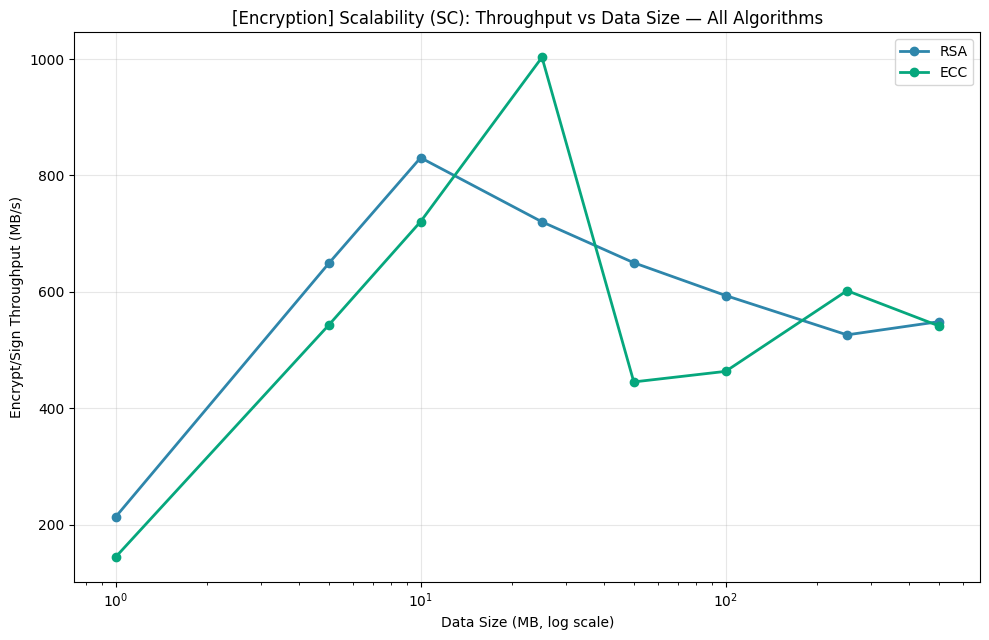

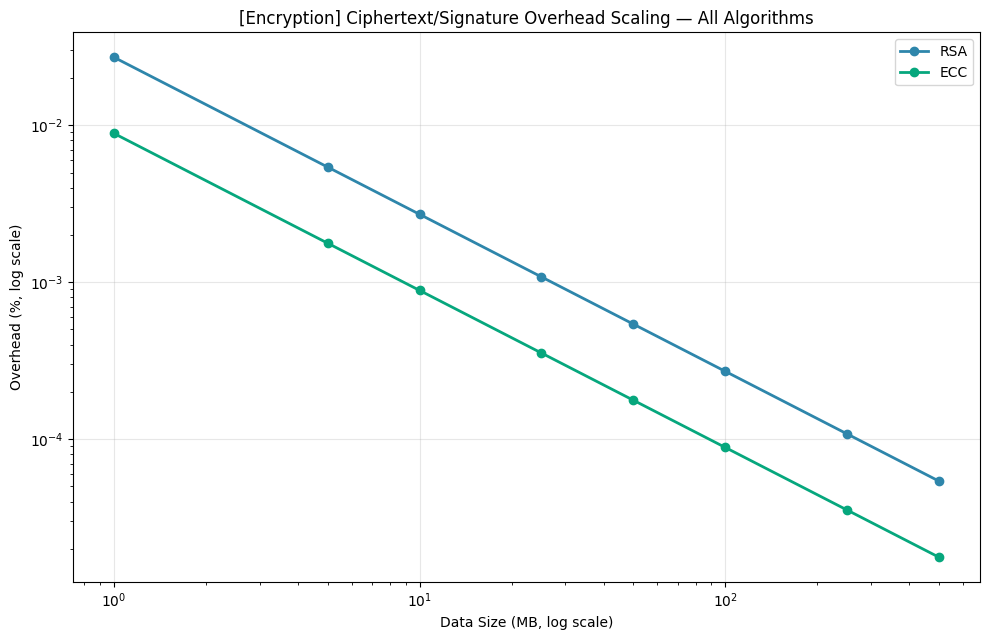


[Encryption] Ranking: ECC=80.0, RSA=20.0


,Algorithm,KGT_mean_ms,KGT_CV_%,ET_mean_ms,DT_mean_ms,CSO_%,MC_KeyGen_KB,CPU%_KeyGen,EC_KeyGen_mJ,TP_maxsize_MBps,Security_bits,Speedup_vs_RSA,Composite_Score
0,RSA,1165.554089,72.439501,4.068932,4.958609,40.749041,1.725195,98.777638,17269.6020,548.922875,112,1.000000,20.0
1,ECC,0.439825,47.450277,6.482330,4.329230,13.343876,1.114258,103.018269,6.7965,541.679242,128,2650.041161,80.0


In [21]:
enc_results = {"RSA": enc_RSA, "ECC": enc_ECC}
enc_df, enc_ranked = compare_within_aspect("Encryption", enc_results, BASE_OUT_DIR)
display(enc_df)

## Compare: Digital Signature (RSA vs ECC vs DSA)

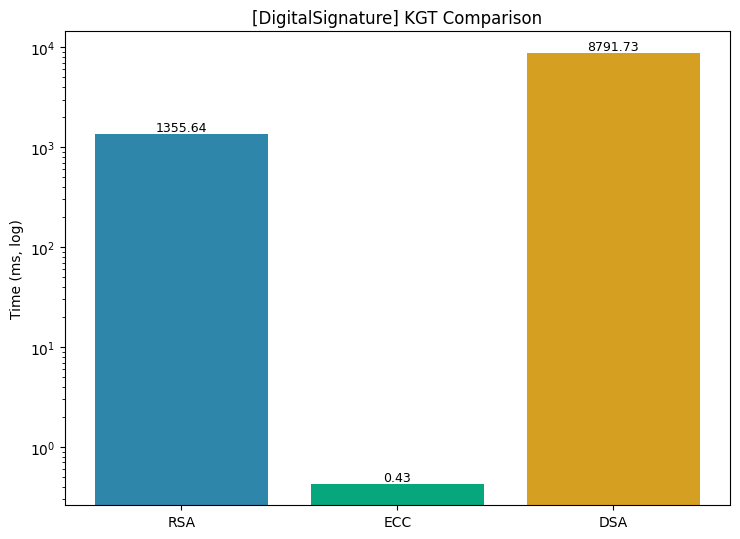

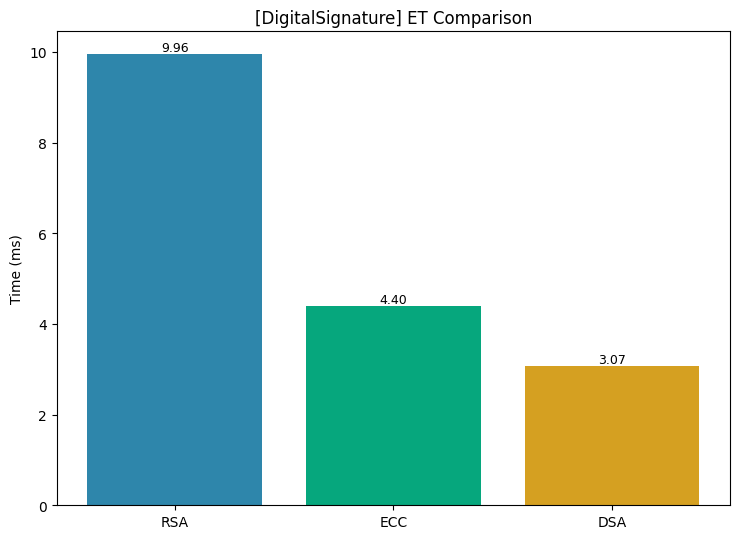

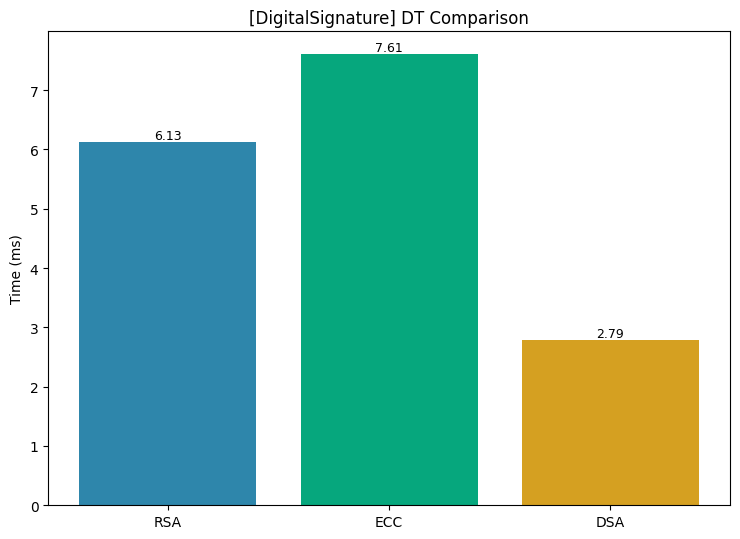

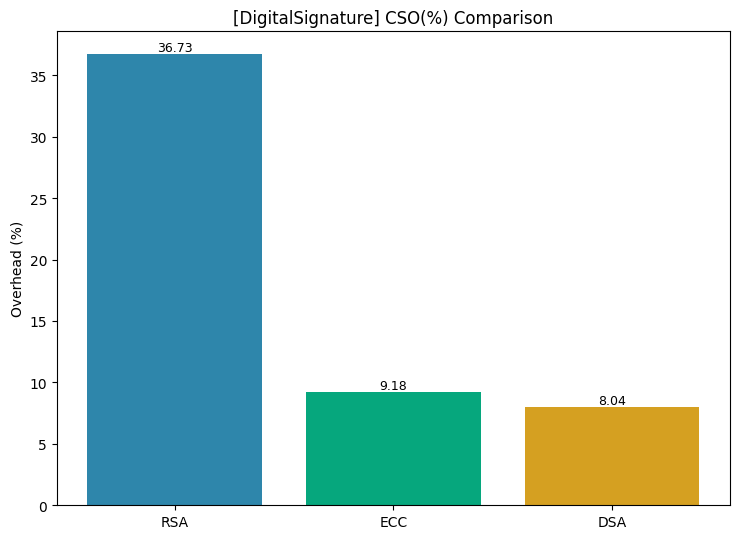

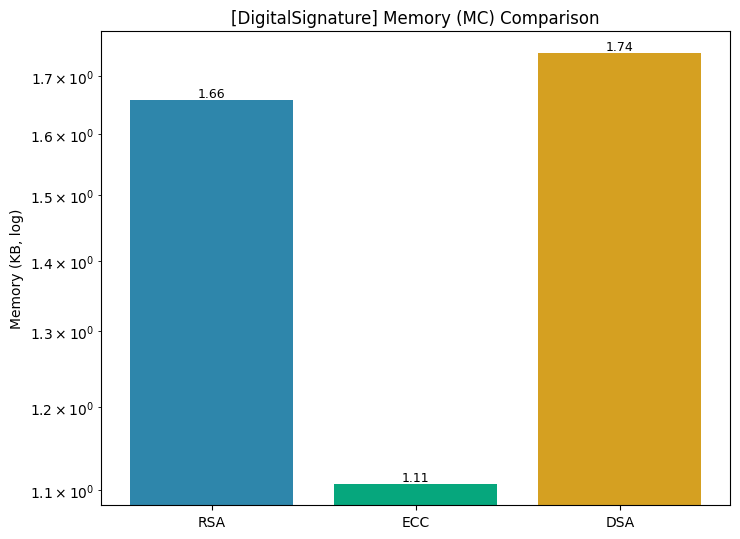

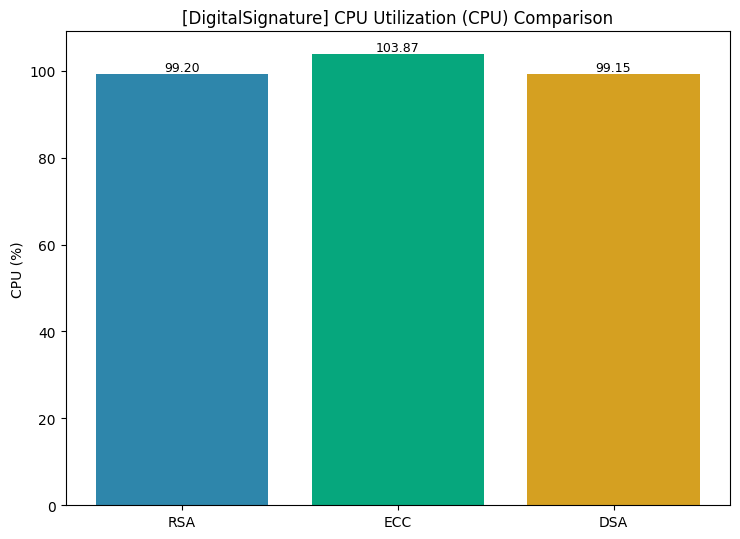

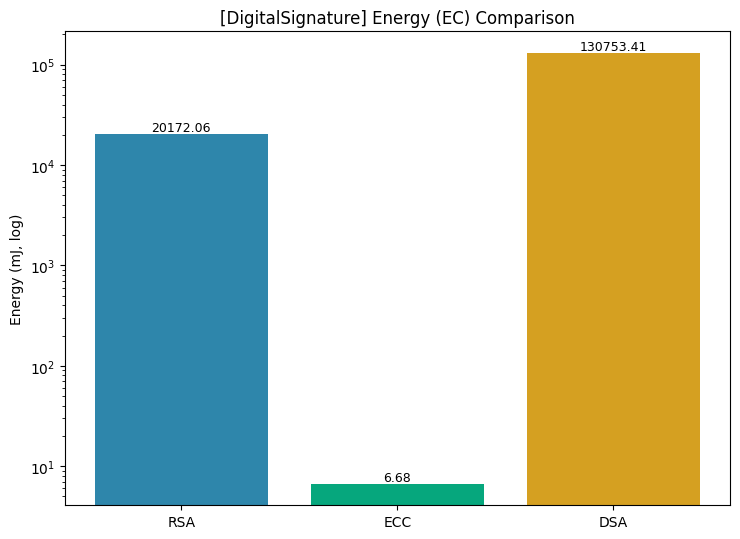

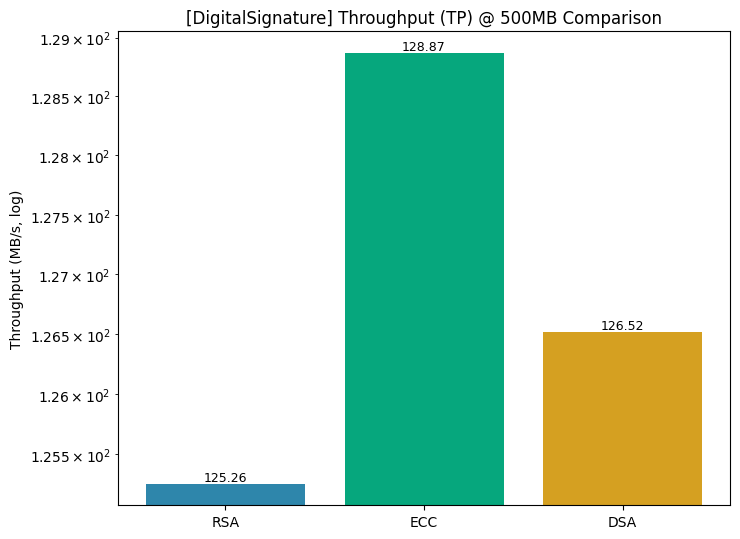

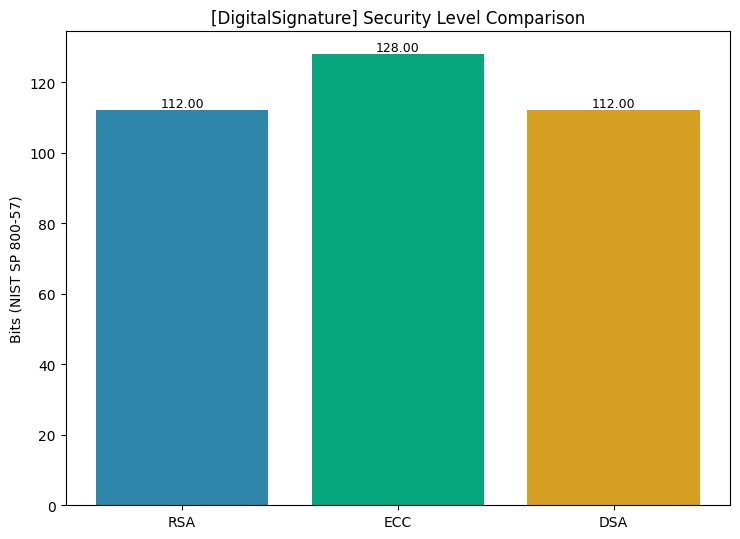

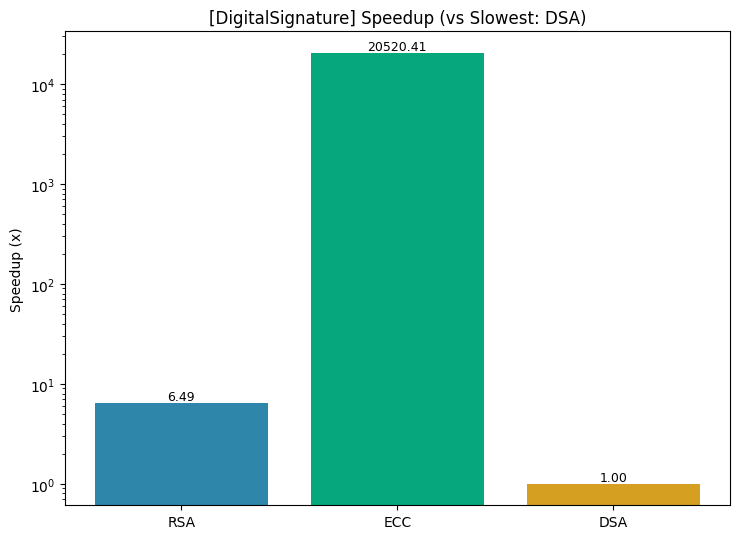

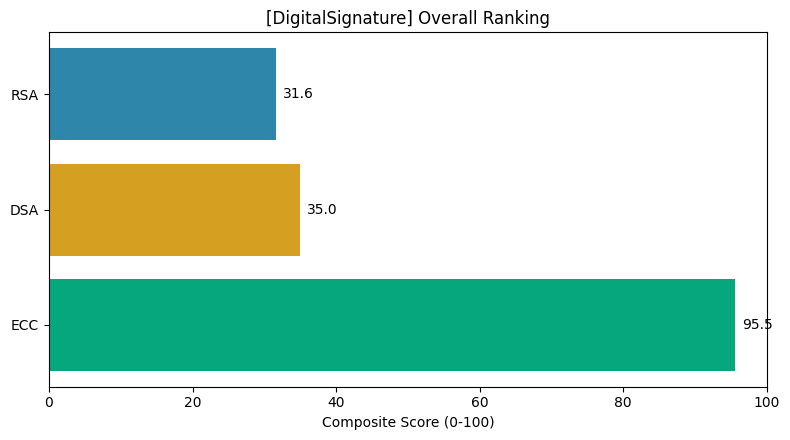

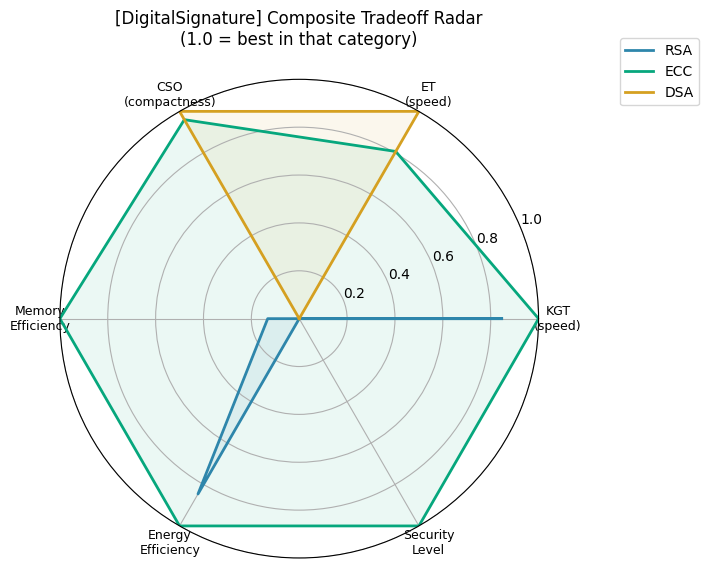

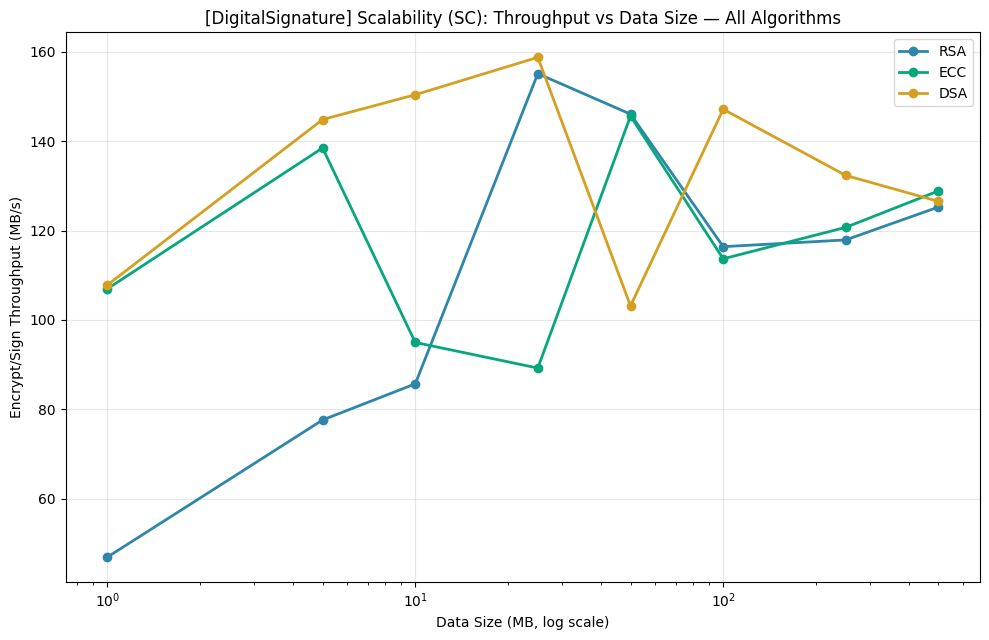

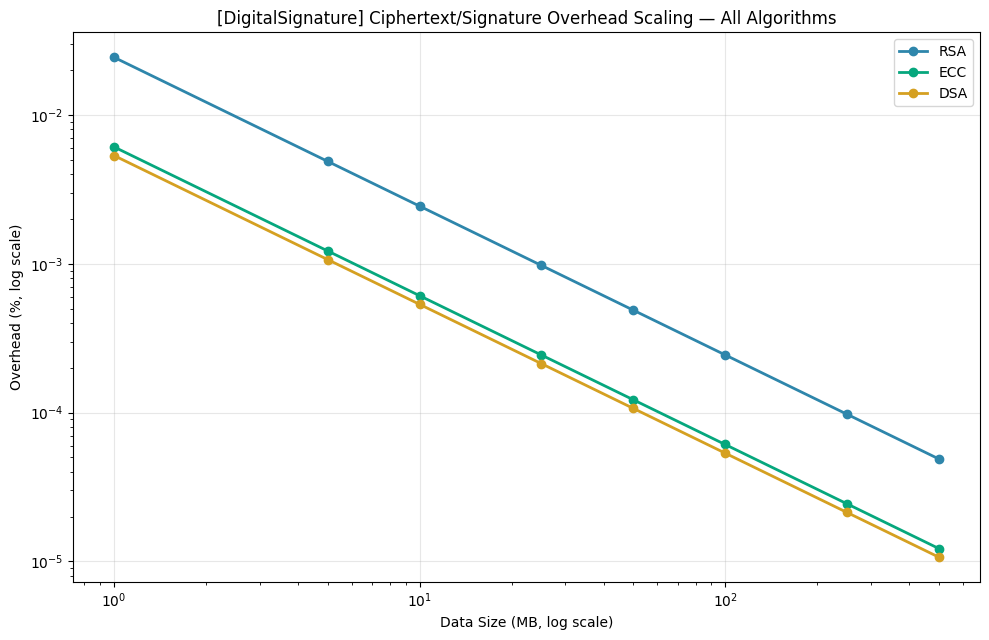


[DigitalSignature] Ranking: ECC=95.5, DSA=35.0, RSA=31.6


,Algorithm,KGT_mean_ms,KGT_CV_%,ET_mean_ms,DT_mean_ms,CSO_%,MC_KeyGen_KB,CPU%_KeyGen,EC_KeyGen_mJ,TP_maxsize_MBps,Security_bits,Speedup_vs_DSA,Composite_Score
0,RSA,1355.642432,48.052627,9.955398,6.126096,36.731530,1.658984,99.200510,20172.0630,125.256324,112,6.485285,31.6
1,ECC,0.428438,30.355862,4.397246,7.610943,9.182883,1.107227,103.865622,6.6750,128.869329,128,20520.410736,95.5
2,DSA,8791.727840,112.337322,3.065103,2.794384,8.035022,1.742676,99.148819,130753.4145,126.517103,112,1.000000,35.0


In [22]:
sig_results = {"RSA": sig_RSA, "ECC": sig_ECC, "DSA": sig_DSA}
sig_df, sig_ranked = compare_within_aspect("DigitalSignature", sig_results, BASE_OUT_DIR)
display(sig_df)

## Compare: Key Exchange (ECC vs DH)

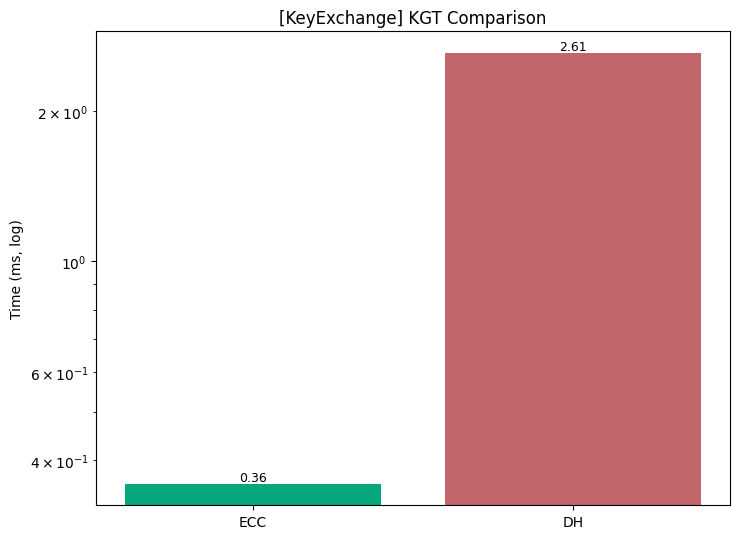

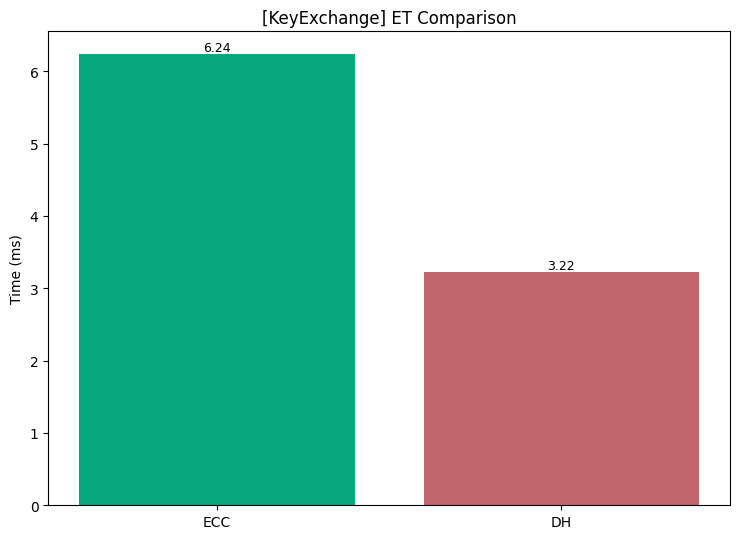

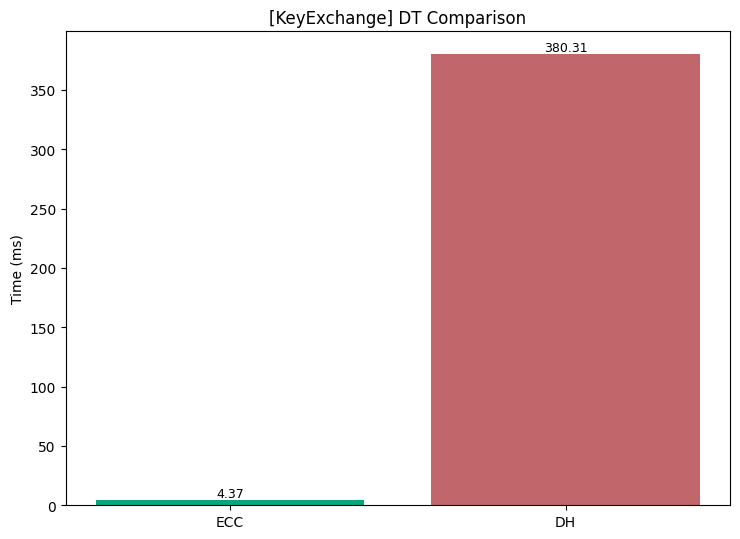

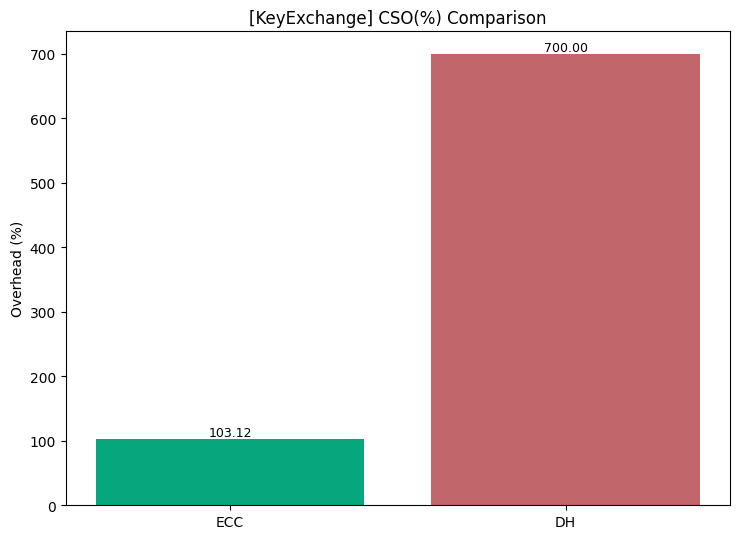

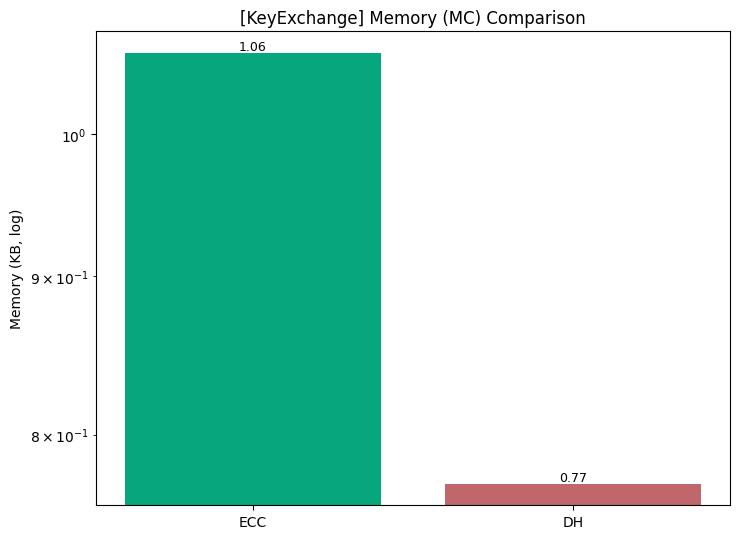

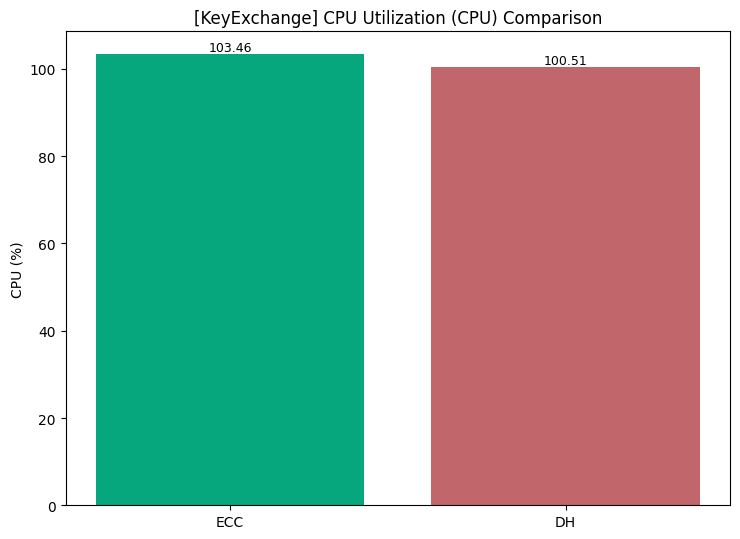

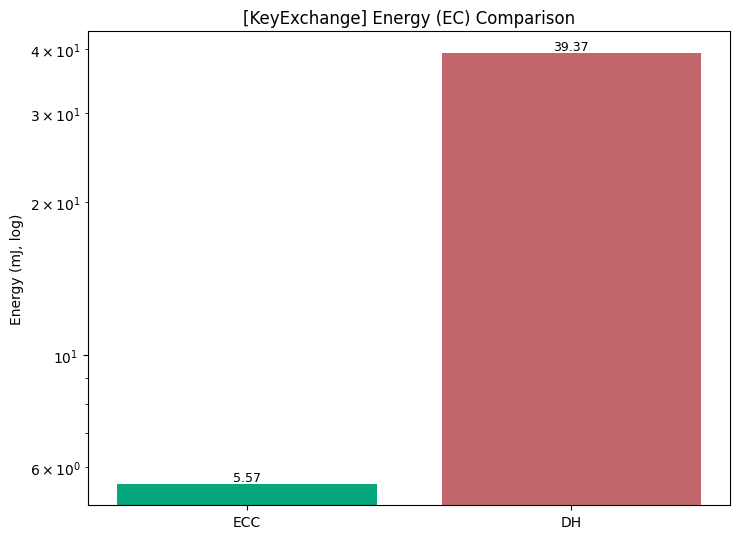

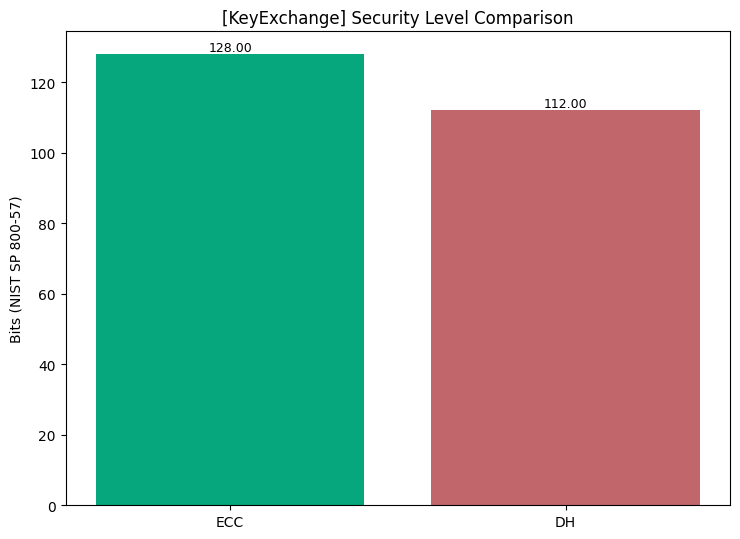

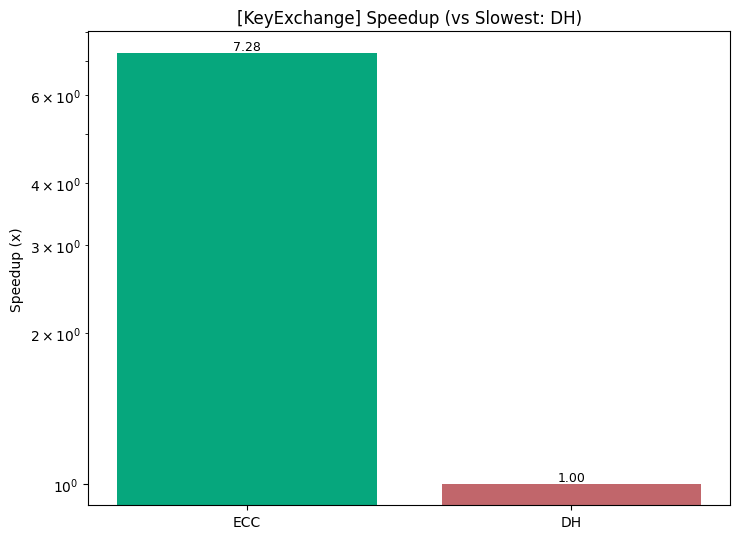

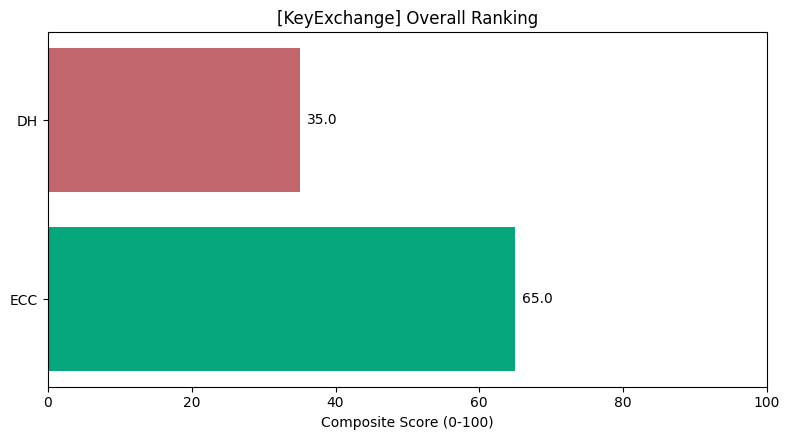

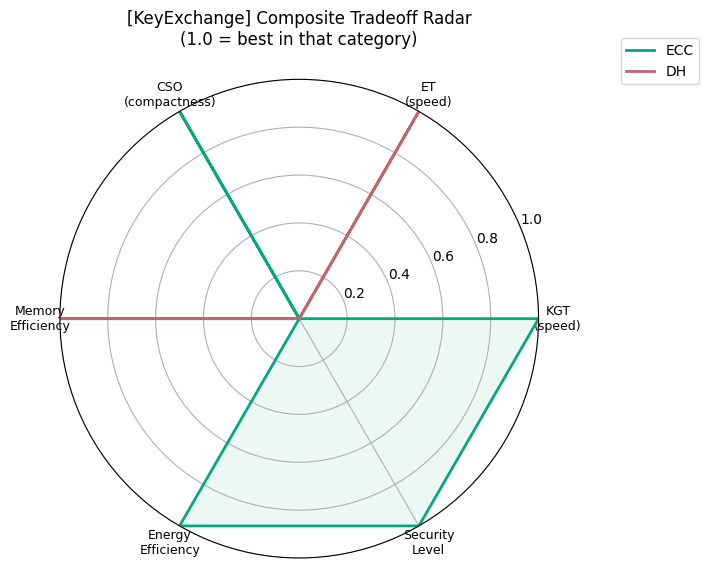


[KeyExchange] Ranking: ECC=65.0, DH=35.0


,Algorithm,KGT_mean_ms,KGT_CV_%,ET_mean_ms,DT_mean_ms,CSO_%,MC_KeyGen_KB,CPU%_KeyGen,EC_KeyGen_mJ,Security_bits,Speedup_vs_DH,Composite_Score
0,ECC,0.358800,18.801975,6.241068,4.373662,103.125,1.062500,103.455878,5.568,128,7.278292,65.0
1,DH,2.611453,7.079254,3.223416,380.311100,700.000,0.771289,100.511087,39.372,112,1.000000,35.0


In [23]:
kex_results = {"ECC": kex_ECC, "DH": kex_DH}
kex_df, kex_ranked = compare_within_aspect("KeyExchange", kex_results, BASE_OUT_DIR, is_keyexchange=True)
display(kex_df)

# Overall Summary — Best Algorithm per PKC Aspect

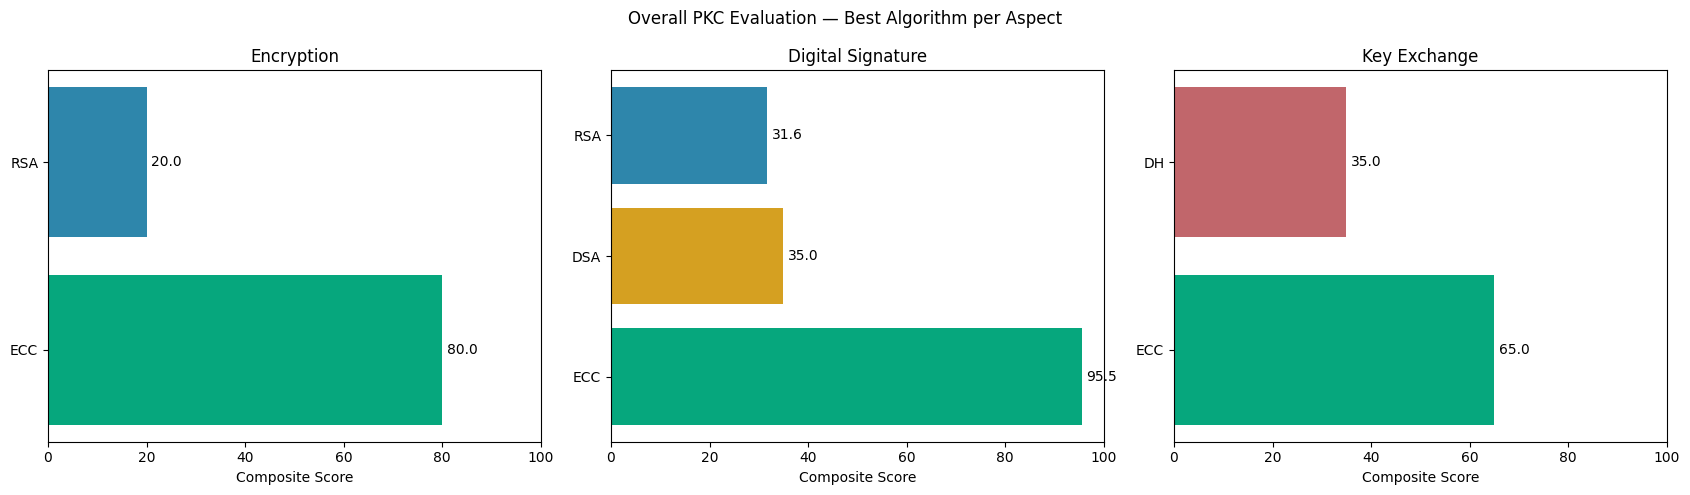


=== FINAL SUMMARY: Best algorithm per PKC aspect ===
Encryption:        ECC (score 80.0)
Digital Signature: ECC (score 95.5)
Key Exchange:      ECC (score 65.0)


In [24]:
overall_summary(enc_ranked, sig_ranked, kex_ranked, BASE_OUT_DIR)

# General Evaluation Metrics (Distribution Stats + Statistical Significance)

Full distribution (mean/median/min/max/std/CV%/95% CI) for KGT and ET per algorithm, plus pairwise Welch's t-test significance testing between every pair of algorithms per aspect.

In [25]:
from scipy import stats as sstats2

def general_evaluation_metrics(aspect, results_dict, out_base_dir, is_keyexchange=False):
    """The 'general evaluation metrics' layer requested earlier: full distribution
    stats (mean/median/min/max/std/CV%/95%CI) for KGT and ET, PLUS pairwise
    statistical significance testing (Welch's t-test) between every pair of
    algorithms tested for this aspect - not just a single averaged number."""
    out_dir = os.path.join(out_base_dir, aspect, "Comparison")
    os.makedirs(out_dir, exist_ok=True)
    names = list(results_dict.keys())
    C = {"RSA": "#2E86AB", "ECC": "#06A77D", "DH": "#C1666B", "DSA": "#D5A021"}

    def get_stats(r, key):
        return r["kgt"] if key == "KGT" else (r["et_initiator"] if is_keyexchange else r["et"])

    # ---------------- Distribution stats table (KGT and ET) ----------------
    rows = []
    for metric in ["KGT", "ET"]:
        for n in names:
            s = get_stats(results_dict[n], metric)
            rows.append({
                "Aspect": aspect, "Metric": metric, "Algorithm": n,
                "Mean_ms": s["mean"], "Median_ms": s["median"], "Min_ms": s["min"], "Max_ms": s["max"],
                "Std_ms": s["std"], "CV_%": s["cv_pct"], "CI95_lower": s["ci95_lower"], "CI95_upper": s["ci95_upper"],
                "N": s["n"],
            })
    general_df = pd.DataFrame(rows)
    general_df.to_csv(os.path.join(out_dir, f"{aspect}_general_eval_metrics.csv"), index=False)

    # ---------------- Pairwise significance testing (Welch's t-test) ----------------
    sig_rows = []
    for metric in ["KGT", "ET"]:
        import itertools
        for a, b in itertools.combinations(names, 2):
            raw_a = get_stats(results_dict[a], metric)["raw"]
            raw_b = get_stats(results_dict[b], metric)["raw"]
            t_stat, p_val = sstats2.ttest_ind(raw_a, raw_b, equal_var=False)
            sig_rows.append({
                "Aspect": aspect, "Metric": metric, "Comparison": f"{a} vs {b}",
                "t_statistic": t_stat, "p_value": p_val, "significant_at_0.05": bool(p_val < 0.05),
            })
    sig_df = pd.DataFrame(sig_rows)
    sig_df.to_csv(os.path.join(out_dir, f"{aspect}_significance_tests.csv"), index=False)

    # ---------------- Combined boxplots: KGT and ET distributions, all algos ----------------
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, metric in zip(axes, ["KGT", "ET"]):
        raw_lists = [get_stats(results_dict[n], metric)["raw"] for n in names]
        bp = ax.boxplot(raw_lists, tick_labels=names, patch_artist=True, showmeans=True)
        for patch, n in zip(bp['boxes'], names):
            patch.set_facecolor(C[n]); patch.set_alpha(0.6)
        ax.set_yscale("log")
        ax.set_ylabel(f"{metric} (ms, log scale)")
        ax.set_title(f"[{aspect}] {metric} Distribution Comparison")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "general_eval_boxplots.png"), dpi=150); plt.show()

    print(f"\n[{aspect}] General Evaluation Metrics (distribution stats):")
    display(general_df.round(4))
    print(f"\n[{aspect}] Pairwise Statistical Significance (Welch's t-test, \u03b1=0.05):")
    display(sig_df.round(4))

    return general_df, sig_df

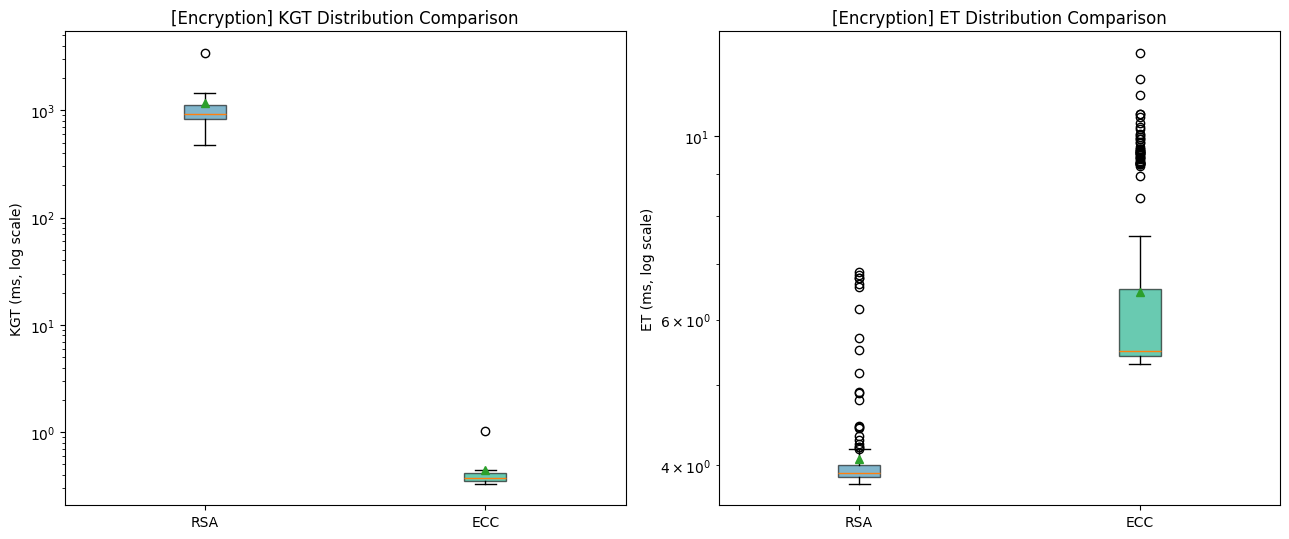


[Encryption] General Evaluation Metrics (distribution stats):


,Aspect,Metric,Algorithm,Mean_ms,Median_ms,Min_ms,Max_ms,Std_ms,CV_%,CI95_lower,CI95_upper,N
0,Encryption,KGT,RSA,1165.5541,931.5484,473.9867,3439.3223,844.3216,72.4395,561.5628,1769.5454,10
1,Encryption,KGT,ECC,0.4398,0.3733,0.3306,1.0250,0.2087,47.4503,0.2905,0.5891,10
2,Encryption,ET,RSA,4.0689,3.9135,3.7970,6.8554,0.5491,13.4960,3.9924,4.1455,200
3,Encryption,ET,ECC,6.4823,5.4990,5.2945,12.6176,1.8049,27.8438,6.2307,6.7340,200



[Encryption] Pairwise Statistical Significance (Welch's t-test, α=0.05):


,Aspect,Metric,Comparison,t_statistic,p_value,significant_at_0.05
0,Encryption,KGT,RSA vs ECC,4.3638,0.0018,True
1,Encryption,ET,RSA vs ECC,-18.0909,0.0000,True


In [26]:
gen_enc, sigtest_enc = general_evaluation_metrics("Encryption", enc_results, BASE_OUT_DIR)

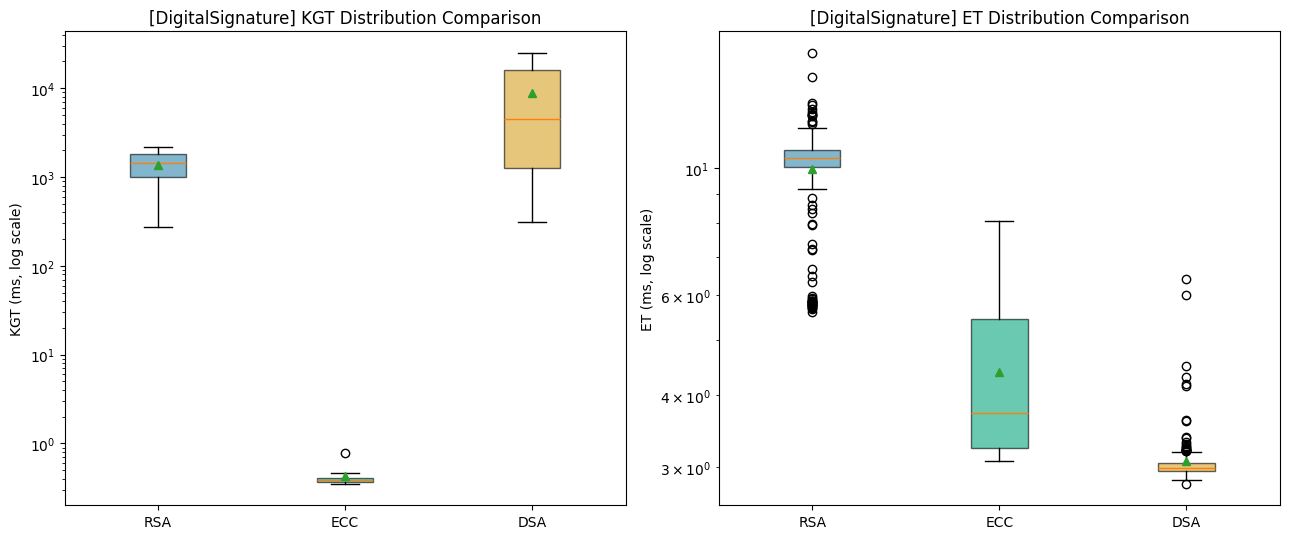


[DigitalSignature] General Evaluation Metrics (distribution stats):


,Aspect,Metric,Algorithm,Mean_ms,Median_ms,Min_ms,Max_ms,Std_ms,CV_%,CI95_lower,CI95_upper,N
0,DigitalSignature,KGT,RSA,1355.6424,1455.2012,276.0477,2179.0872,651.4218,48.0526,889.6434,1821.6415,10
1,DigitalSignature,KGT,ECC,0.4284,0.3894,0.3523,0.7871,0.1301,30.3559,0.3354,0.5215,10
2,DigitalSignature,KGT,DSA,8791.7278,4473.9136,309.7537,24963.1055,9876.3916,112.3373,1726.5829,15856.8728,10
3,DigitalSignature,ET,RSA,9.9554,10.4142,5.5884,15.9134,1.8392,18.4746,9.6989,10.2119,200
4,DigitalSignature,ET,ECC,4.3972,3.7234,3.0688,8.0941,1.2301,27.9740,4.2257,4.5688,200
5,DigitalSignature,ET,DSA,3.0651,2.9855,2.8009,6.4051,0.3810,12.4306,3.0120,3.1182,200



[DigitalSignature] Pairwise Statistical Significance (Welch's t-test, α=0.05):


,Aspect,Metric,Comparison,t_statistic,p_value,significant_at_0.05
0,DigitalSignature,KGT,RSA vs ECC,6.5788,0.0001,True
1,DigitalSignature,KGT,RSA vs DSA,-2.3758,0.0413,True
2,DigitalSignature,KGT,ECC vs DSA,-2.8148,0.0202,True
3,DigitalSignature,ET,RSA vs ECC,35.5249,0.0000,True
4,DigitalSignature,ET,RSA vs DSA,51.8795,0.0000,True
5,DigitalSignature,ET,ECC vs DSA,14.6298,0.0000,True


In [27]:
gen_sig, sigtest_sig = general_evaluation_metrics("DigitalSignature", sig_results, BASE_OUT_DIR)

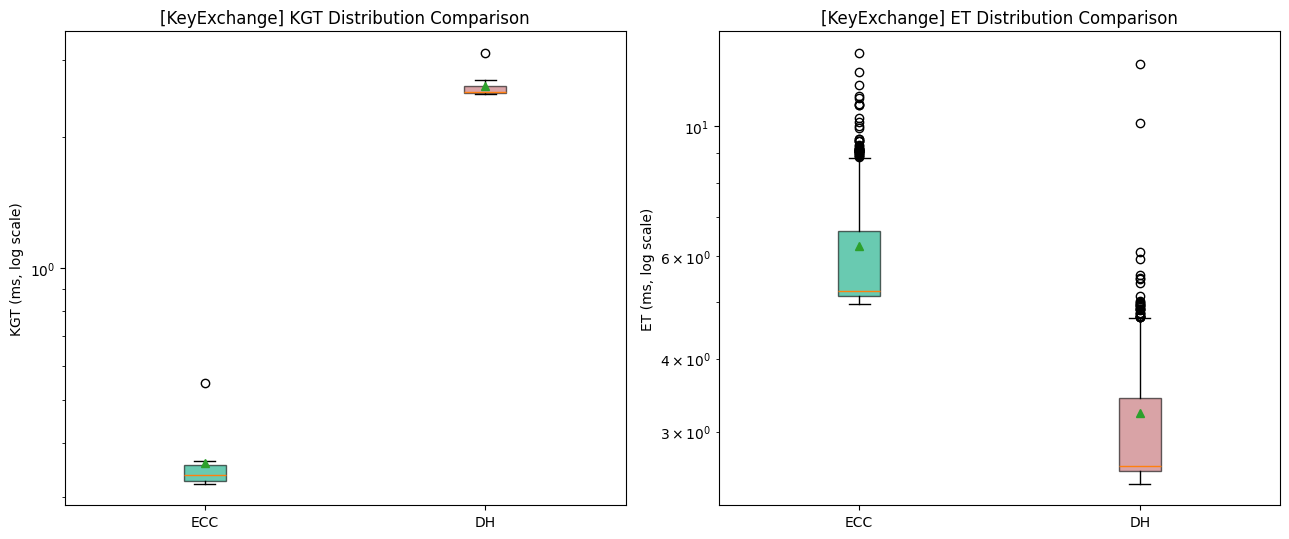


[KeyExchange] General Evaluation Metrics (distribution stats):


,Aspect,Metric,Algorithm,Mean_ms,Median_ms,Min_ms,Max_ms,Std_ms,CV_%,CI95_lower,CI95_upper,N
0,KeyExchange,KGT,ECC,0.3588,0.3369,0.3223,0.5465,0.0675,18.8020,0.3105,0.4071,10
1,KeyExchange,KGT,DH,2.6115,2.5277,2.5067,3.1076,0.1849,7.0793,2.4792,2.7437,10
2,KeyExchange,ET,ECC,6.2411,5.2159,4.9568,13.3459,1.8928,30.3274,5.9771,6.5050,200
3,KeyExchange,ET,DH,3.2234,2.6215,2.4439,12.7959,1.2621,39.1547,3.0474,3.3994,200



[KeyExchange] Pairwise Statistical Significance (Welch's t-test, α=0.05):


,Aspect,Metric,Comparison,t_statistic,p_value,significant_at_0.05
0,KeyExchange,KGT,ECC vs DH,-36.1975,0.0,True
1,KeyExchange,ET,ECC vs DH,18.7590,0.0,True


In [28]:
gen_kex, sigtest_kex = general_evaluation_metrics("KeyExchange", kex_results, BASE_OUT_DIR, is_keyexchange=True)